In [27]:
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R
import matplotlib.pyplot as plt
import numpy as np
import h5py

# Amplitude tests

In [28]:
path_to_amp_data =  f"../../FEW-dev/src/few/data/Amplitudes1PAT1R.h5" # adjust if needed!

In [29]:
from few.amplitude.ampinterp1d import AmpInterp1PAT1R

In [30]:
amp = AmpInterp1PAT1R()

In [31]:
# Define an orbit
a = 0.0
e = 0.0
xI = 1.0

# Get all mode pairs
lm_arr = []
for mode in amp.special_index_map.keys():
    l, m, _, _ = mode
    if m < 0:
        continue
    lm_arr.append((l,m))

## Single component interpolant checks

Evaluate the interpolant for each piece of the amplitude and compare to raw data

In [32]:
def plot_mode_interpolant_vs_nodes(l, m):
    idx = amp.special_index_map[(l, m, 0, 0)]
    
    hdf5_keys = ["0PA", "1PA", "1PAchi1", "1PAchi2"]  # keys with raw data in HDF5
    all_keys  = hdf5_keys + ["delta_m1"]               # delta_m1 is computed, no raw nodes

    # Evaluate interpolants
    p_values = np.linspace(6.25, 30.0, 100)
    amp_values = {
        key: [amp.get_amplitudes_single_piece(a, p, e, xI, data_key=key)[0, idx] for p in p_values]
        for key in hdf5_keys  # only the 4 real spline keys
        }
    amp_values["delta_m1"] = [
        -(2./3. * p) * amp.get_amplitudes_single_piece(a, p, e, xI, data_key="0PA", deriv_order=1)[0, idx]
        for p in p_values]

    # Read raw data (HDF5 keys only)
    raw_data = {}
    with h5py.File(path_to_amp_data, "r") as hf:
        for key in hdf5_keys:
            raw_data[key, "grid"] = np.array(hf.get(f"{key}/Grid"))
            raw_data[key, "real"] = np.array(hf.get(f"{key}/l{l}/m{m}/Infinity"))[:, 0]
            raw_data[key, "imag"] = np.array(hf.get(f"{key}/l{l}/m{m}/Infinity"))[:, 1]

    # Make plot
    plt.figure()
    plt.gcf().set_size_inches(18, 10)

    for i, key in enumerate(all_keys):
        plt.subplot(2, 3, i + 1)
        plt.plot(p_values, np.real(amp_values[key]), label=f"Real {key}")
        plt.plot(p_values, np.imag(amp_values[key]), label=f"Imag {key}")

        # Overlay raw nodes only if HDF5 data exists for this key
        if key in hdf5_keys:
            N_dw = 80
            selected = [N_dw*j for j in range(int(len(raw_data[key, "grid"]) / N_dw))]
            plt.plot(raw_data[key, "grid"][selected], -raw_data[key, "real"][selected],
                     linestyle="None", marker=".", markersize=6)
            plt.plot(raw_data[key, "grid"][selected], -raw_data[key, "imag"][selected],
                     linestyle="None", marker=".", markersize=6)

        plt.xlim(6, p_values[-1])
        plt.xlabel("p")
        plt.grid()
        plt.legend()

    plt.suptitle(f"l={l}, m={m}", fontsize=20)
    plt.gcf().tight_layout()

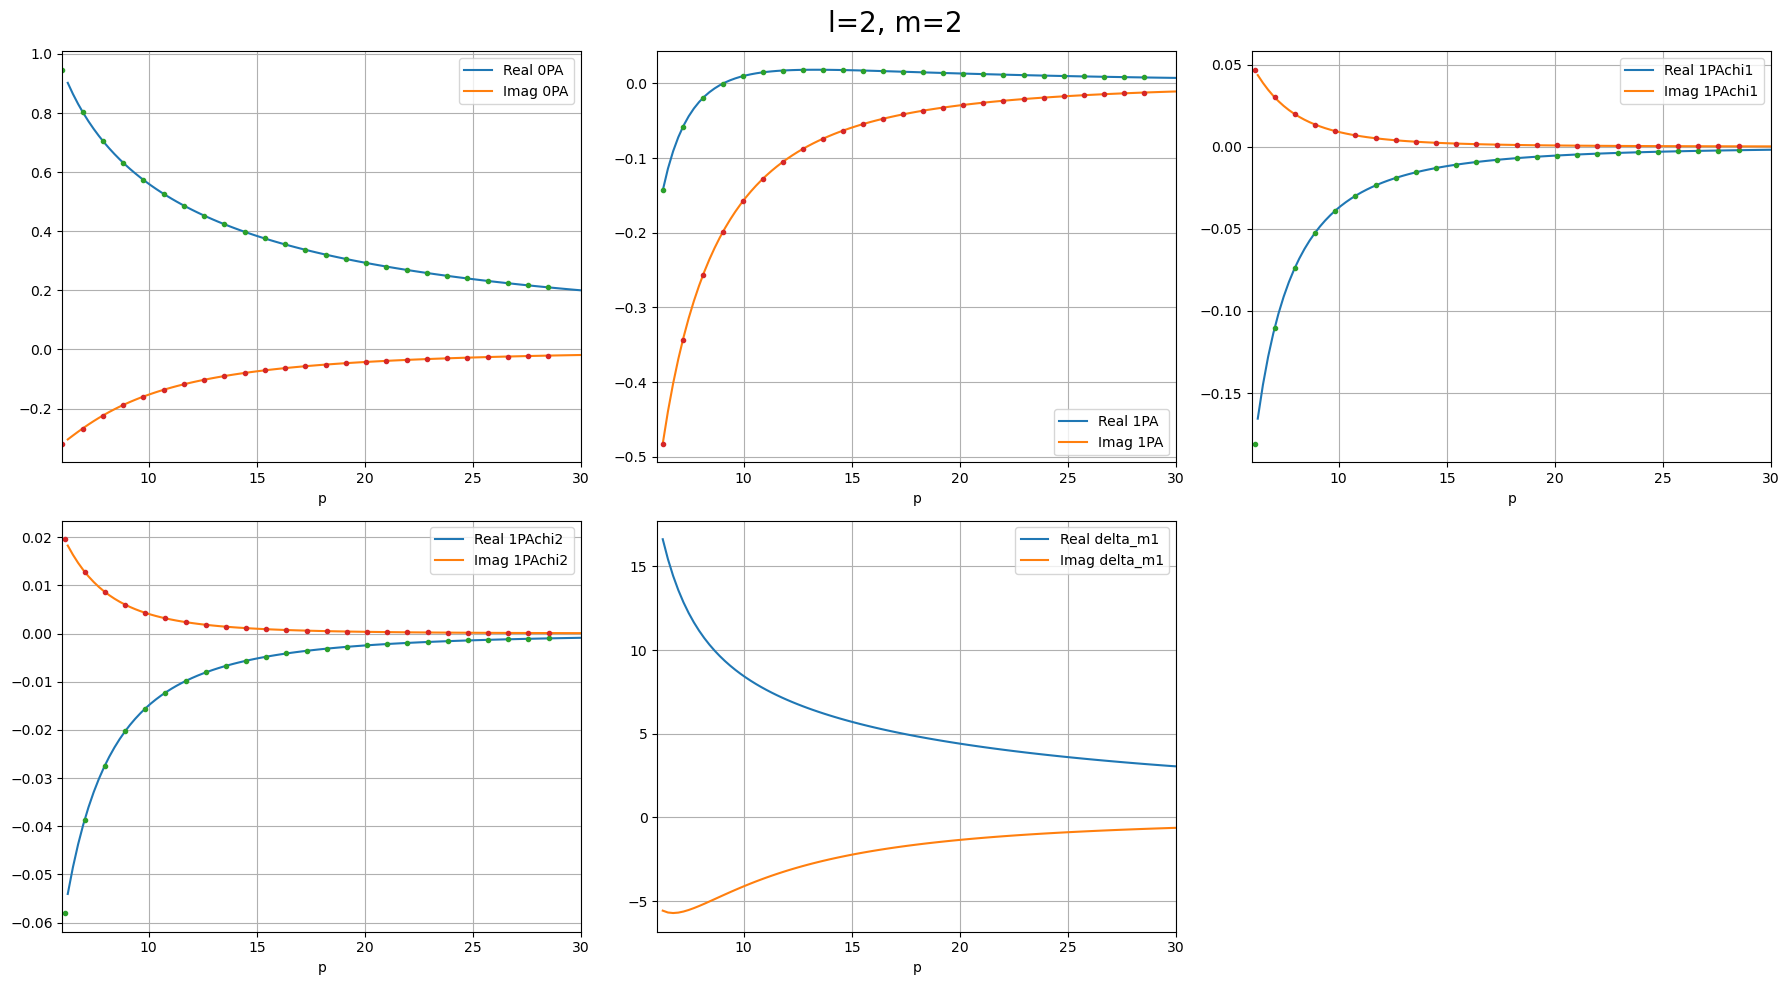

In [33]:
# Plot the (2,2) mode
plot_mode_interpolant_vs_nodes(2,2)

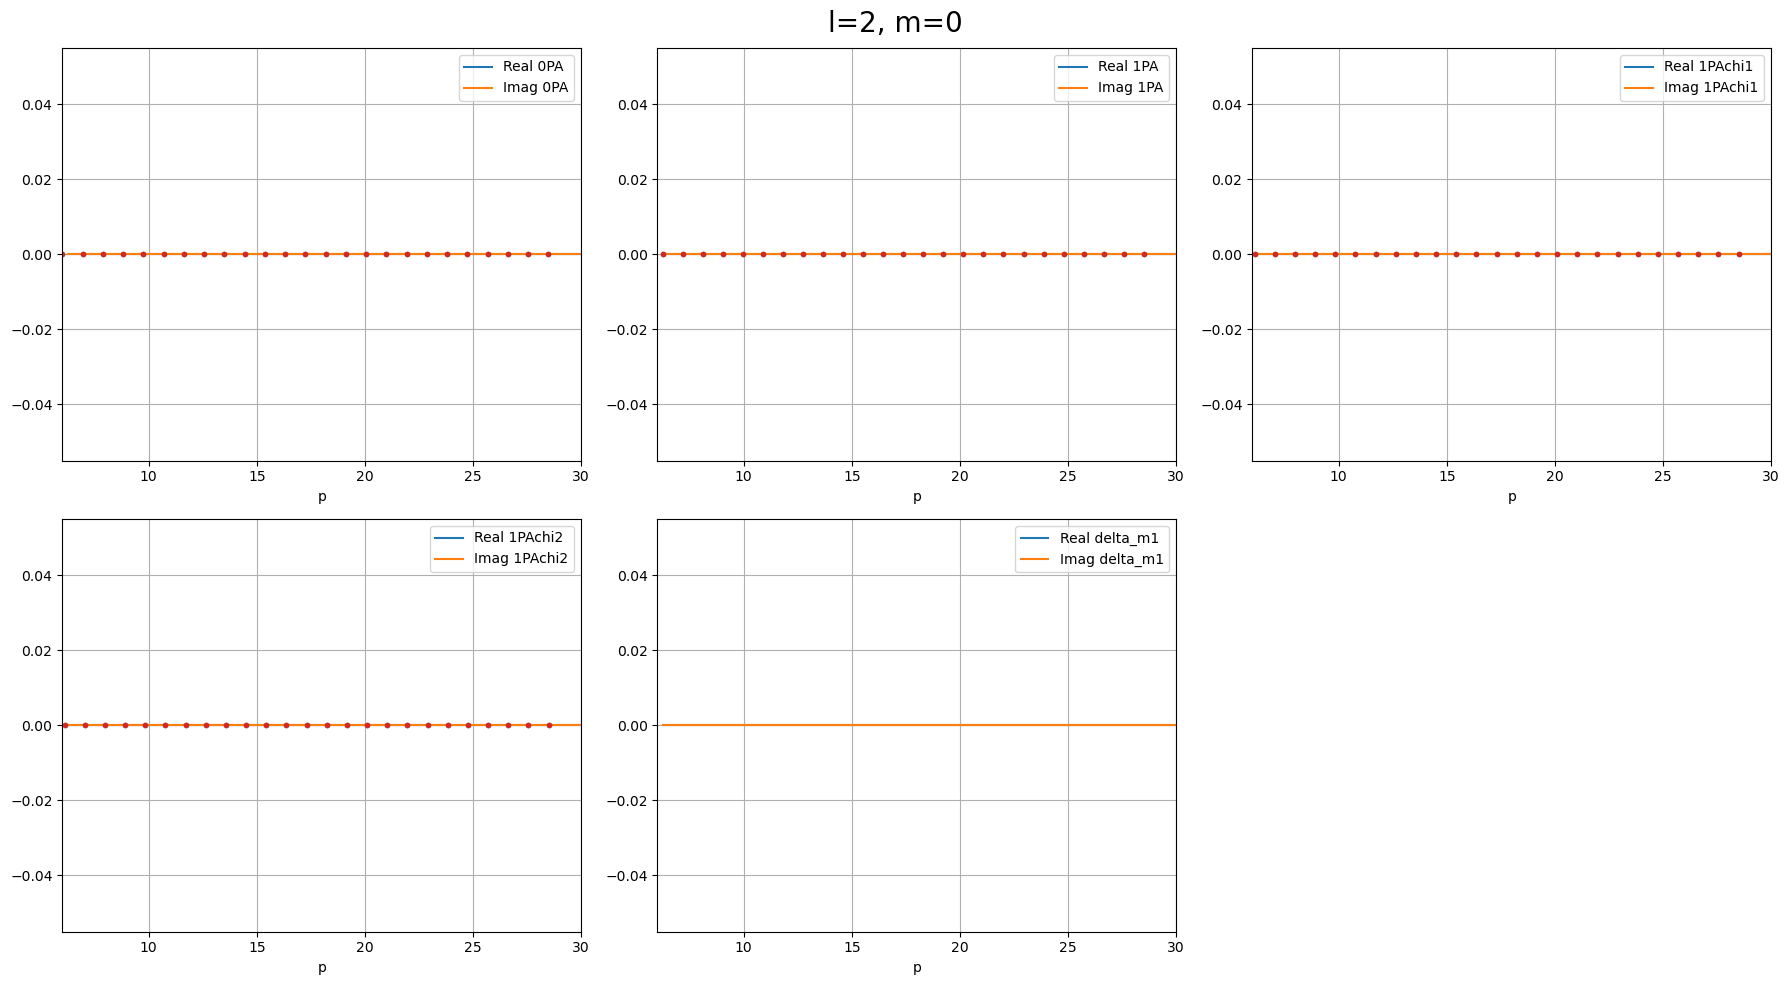

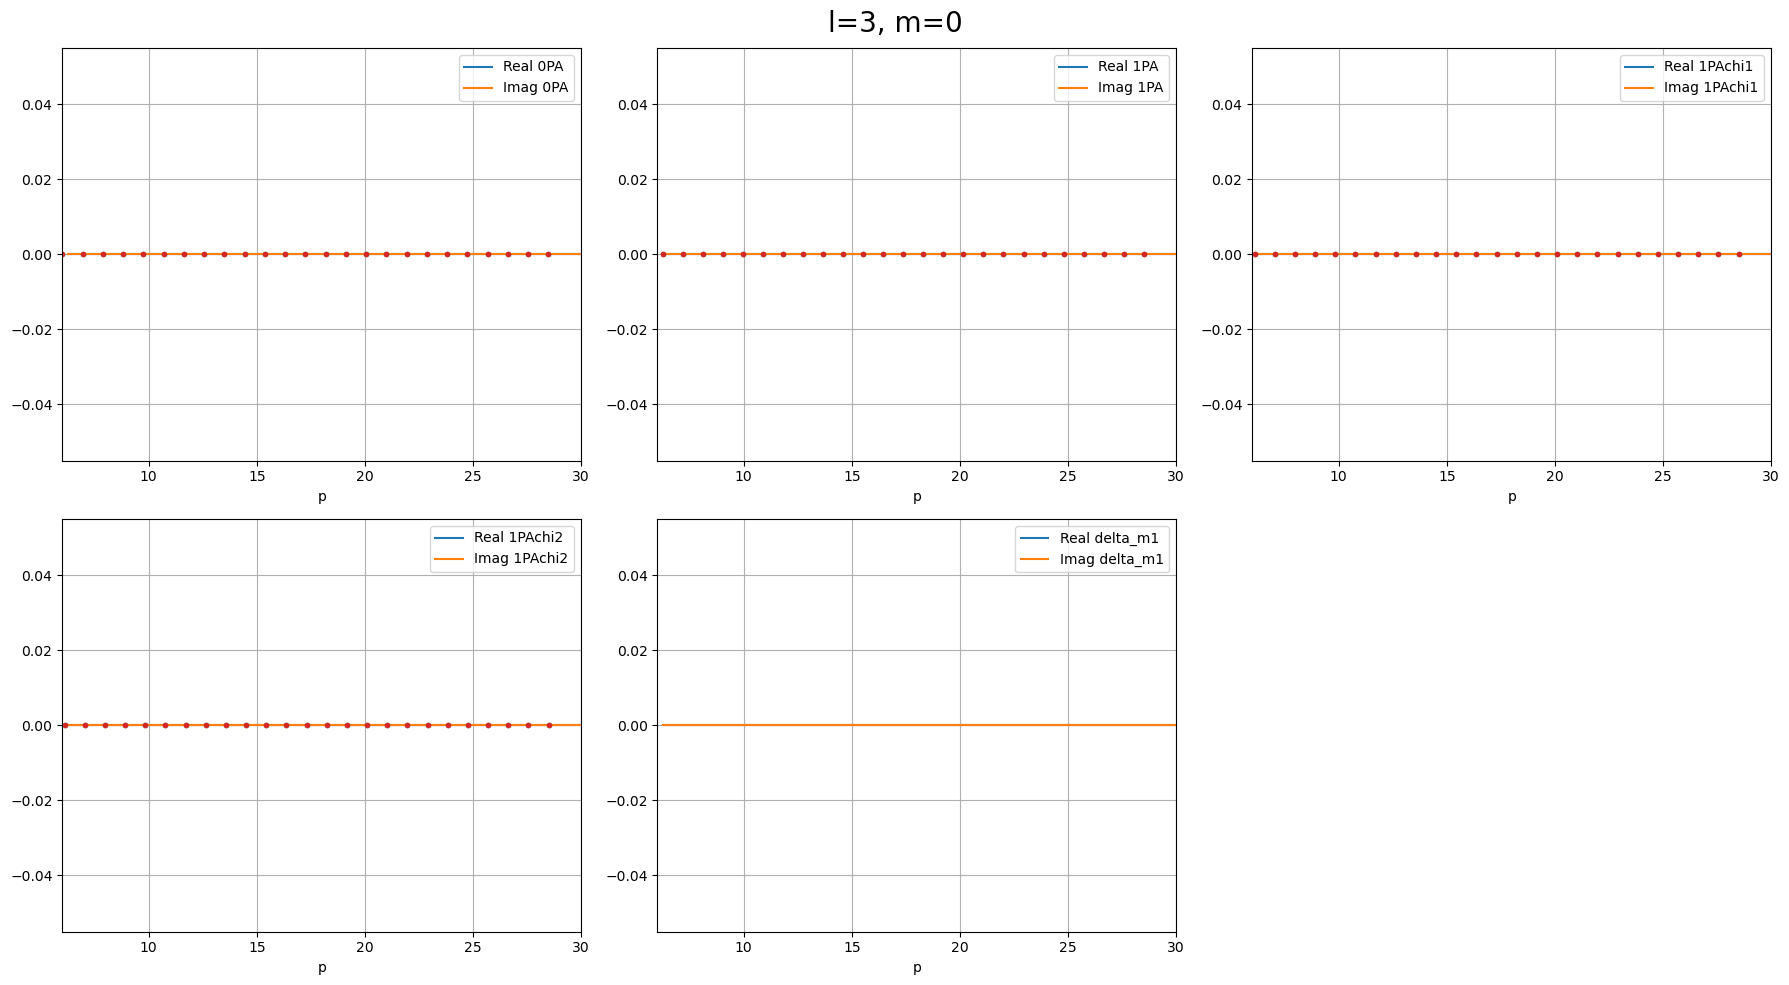

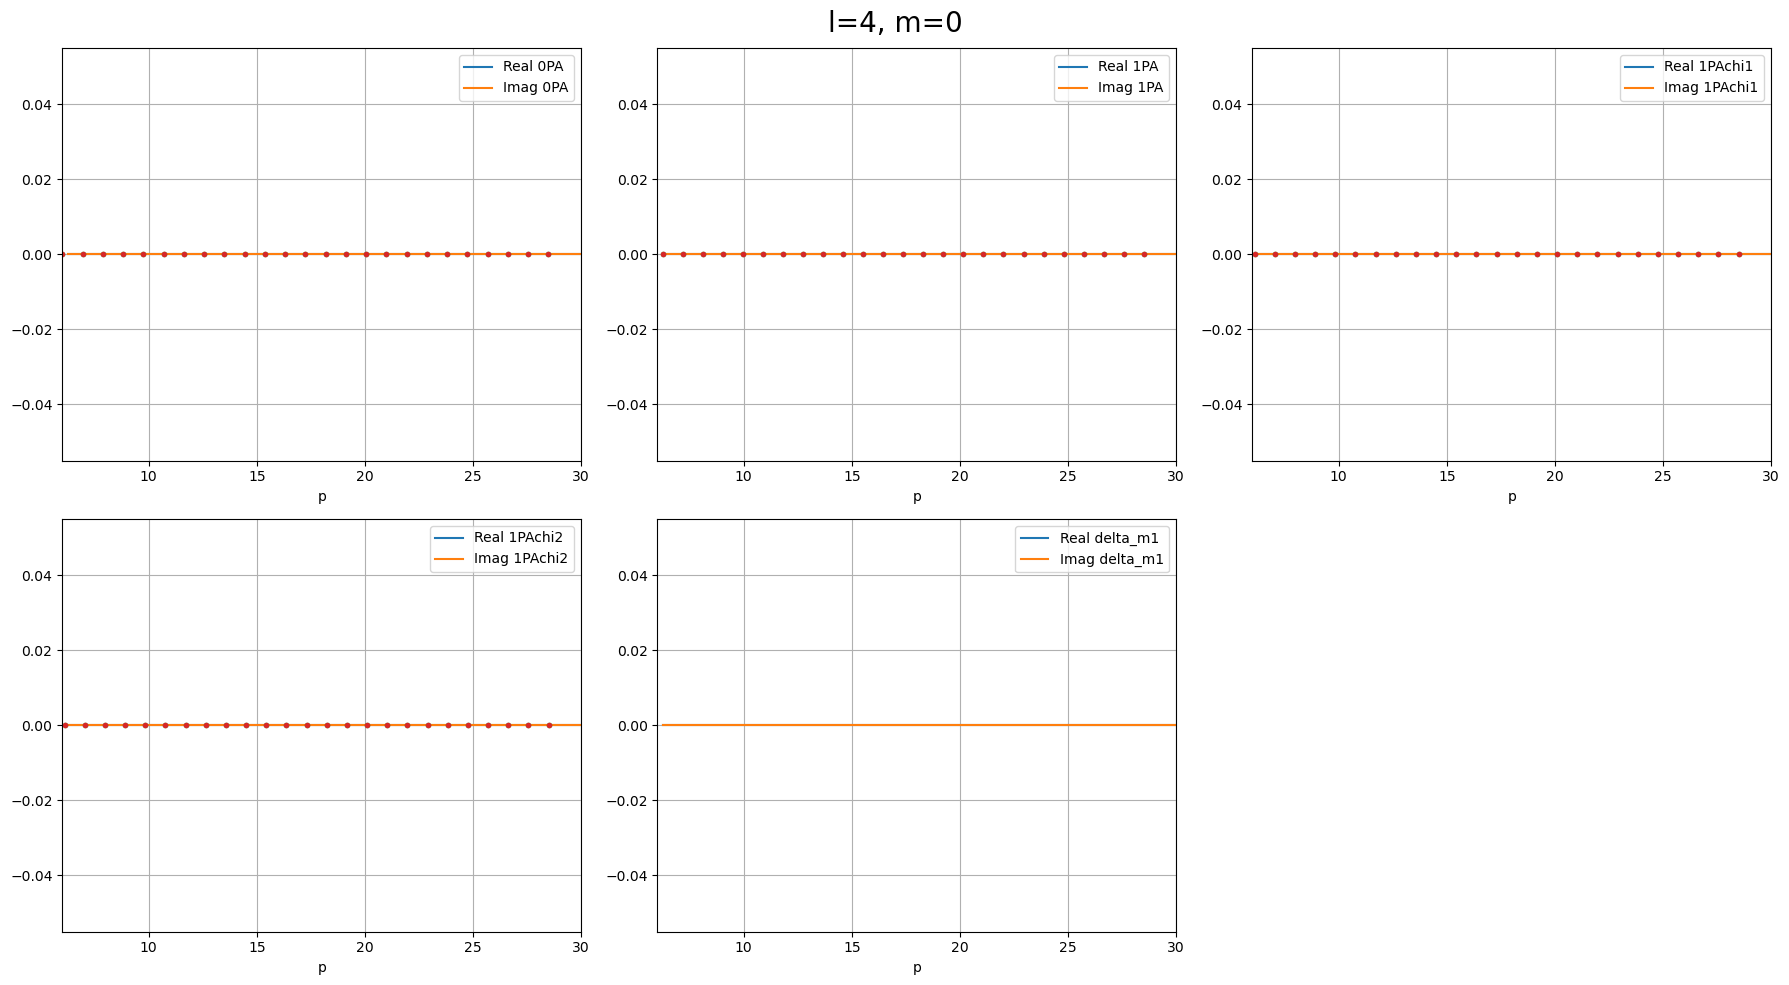

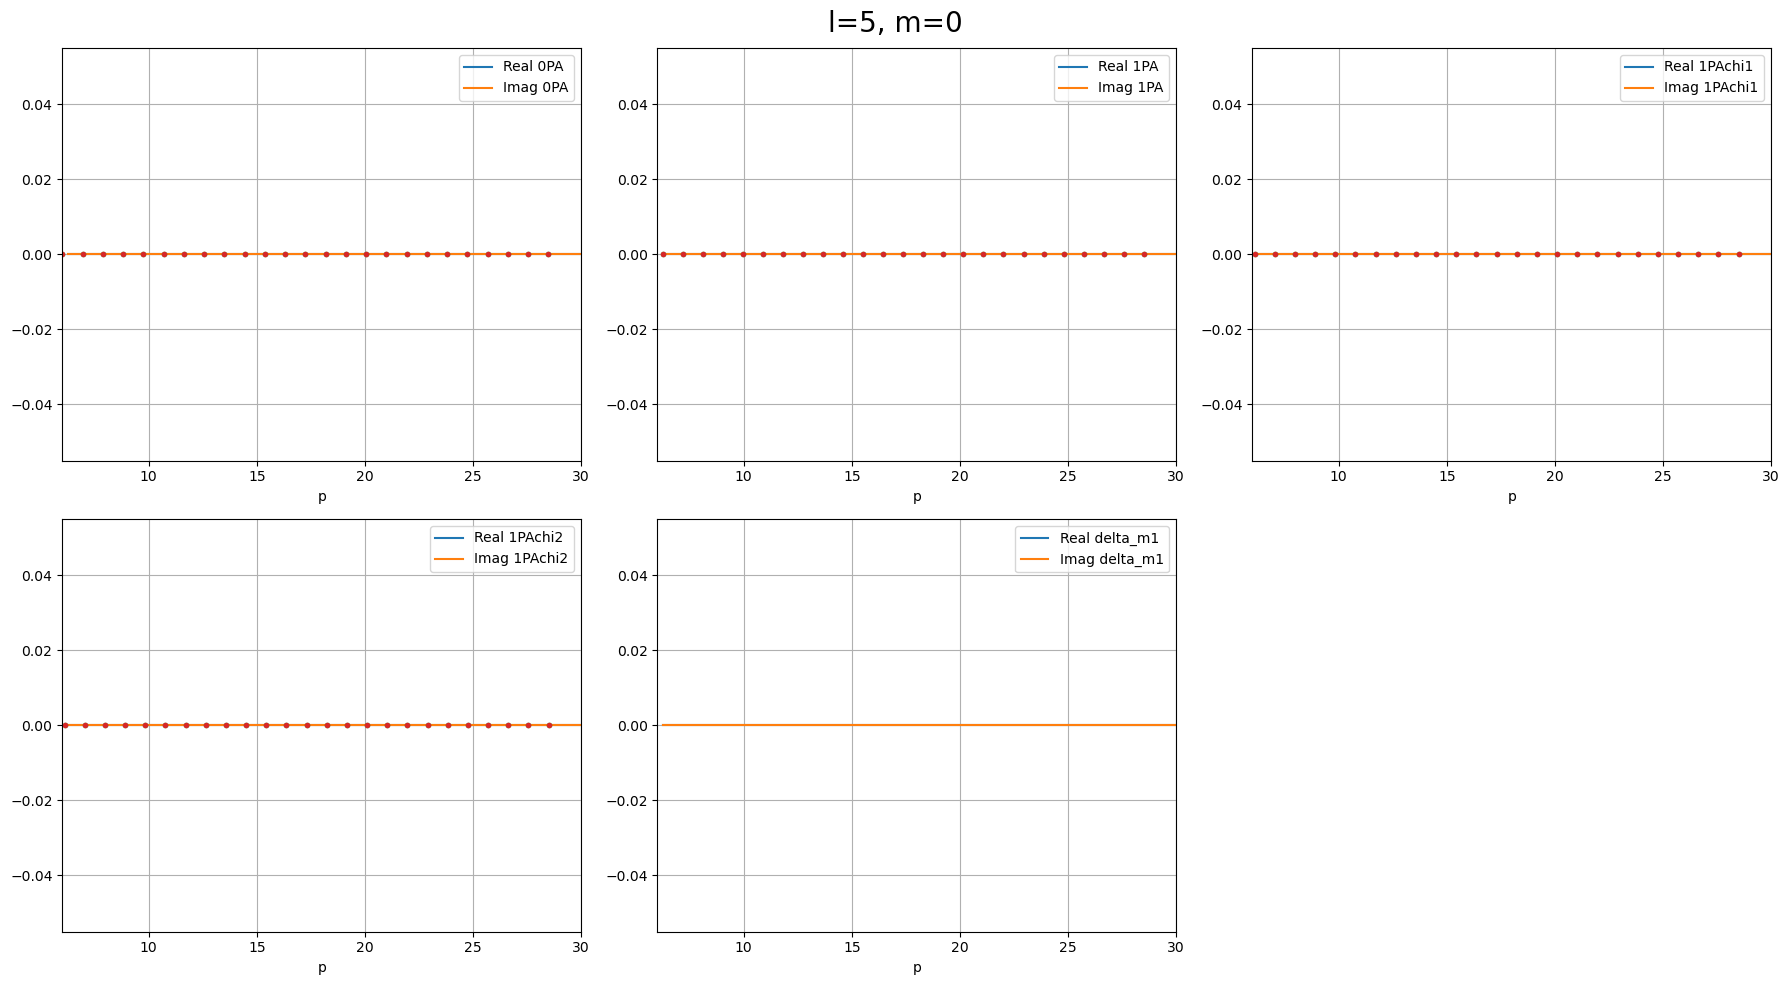

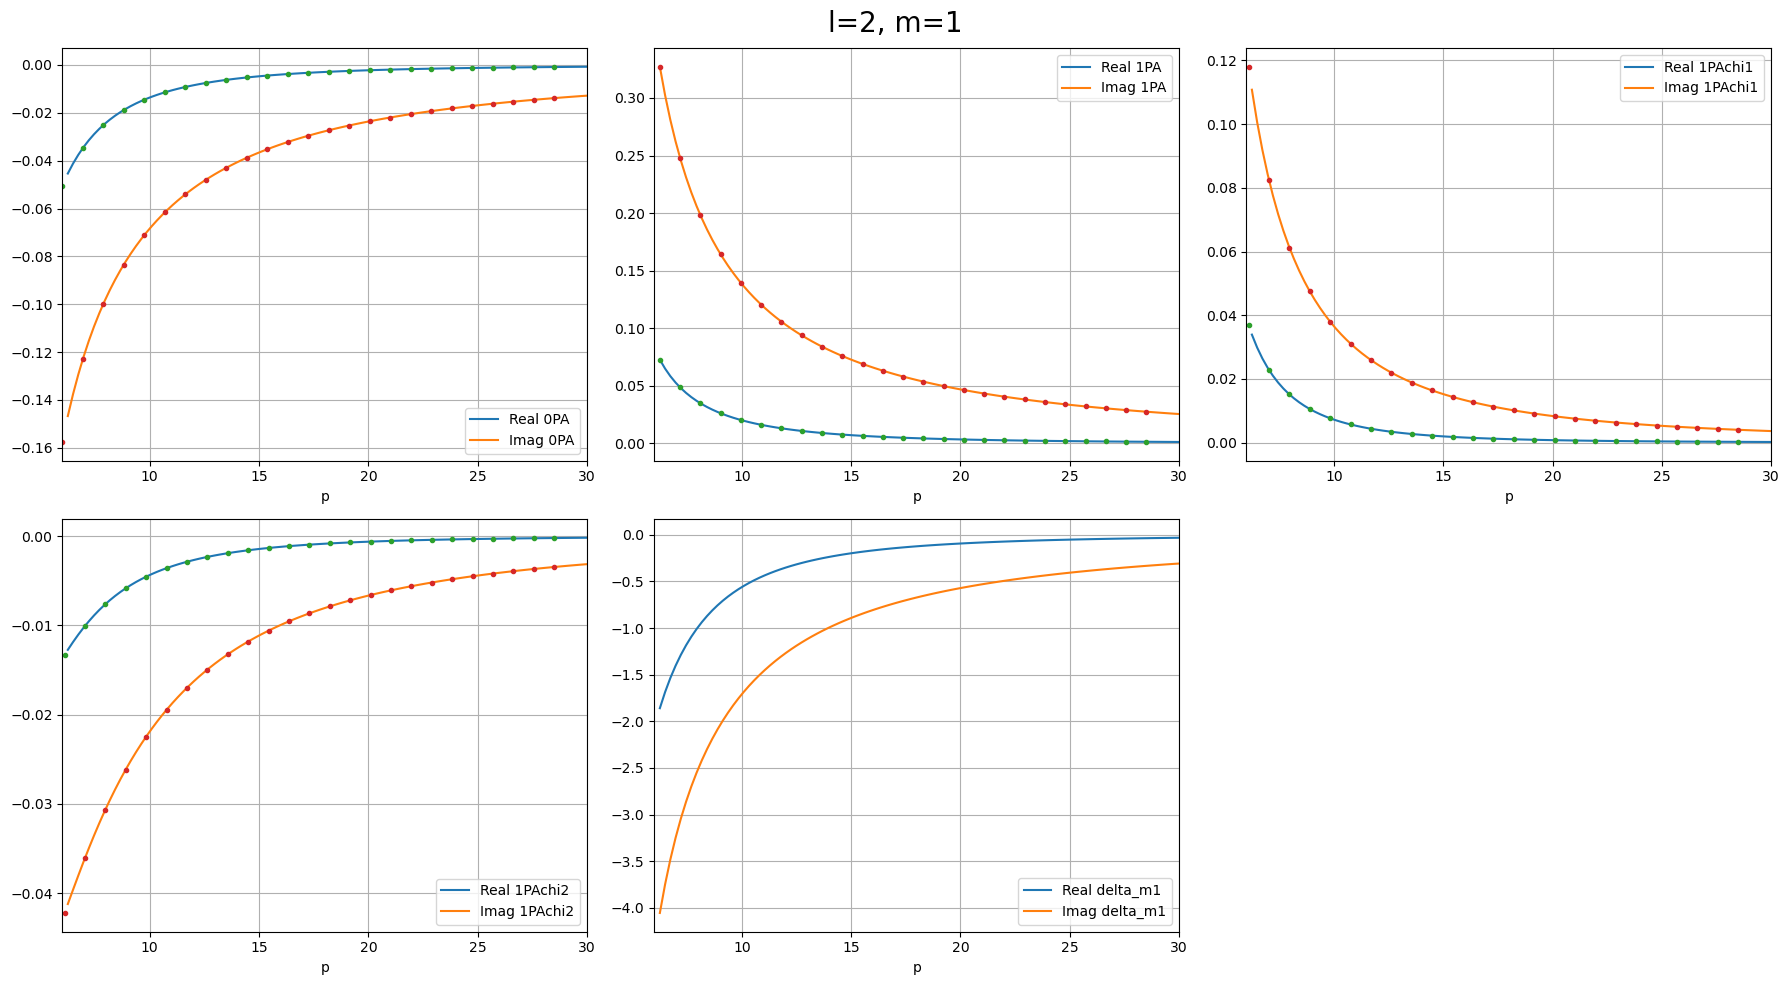

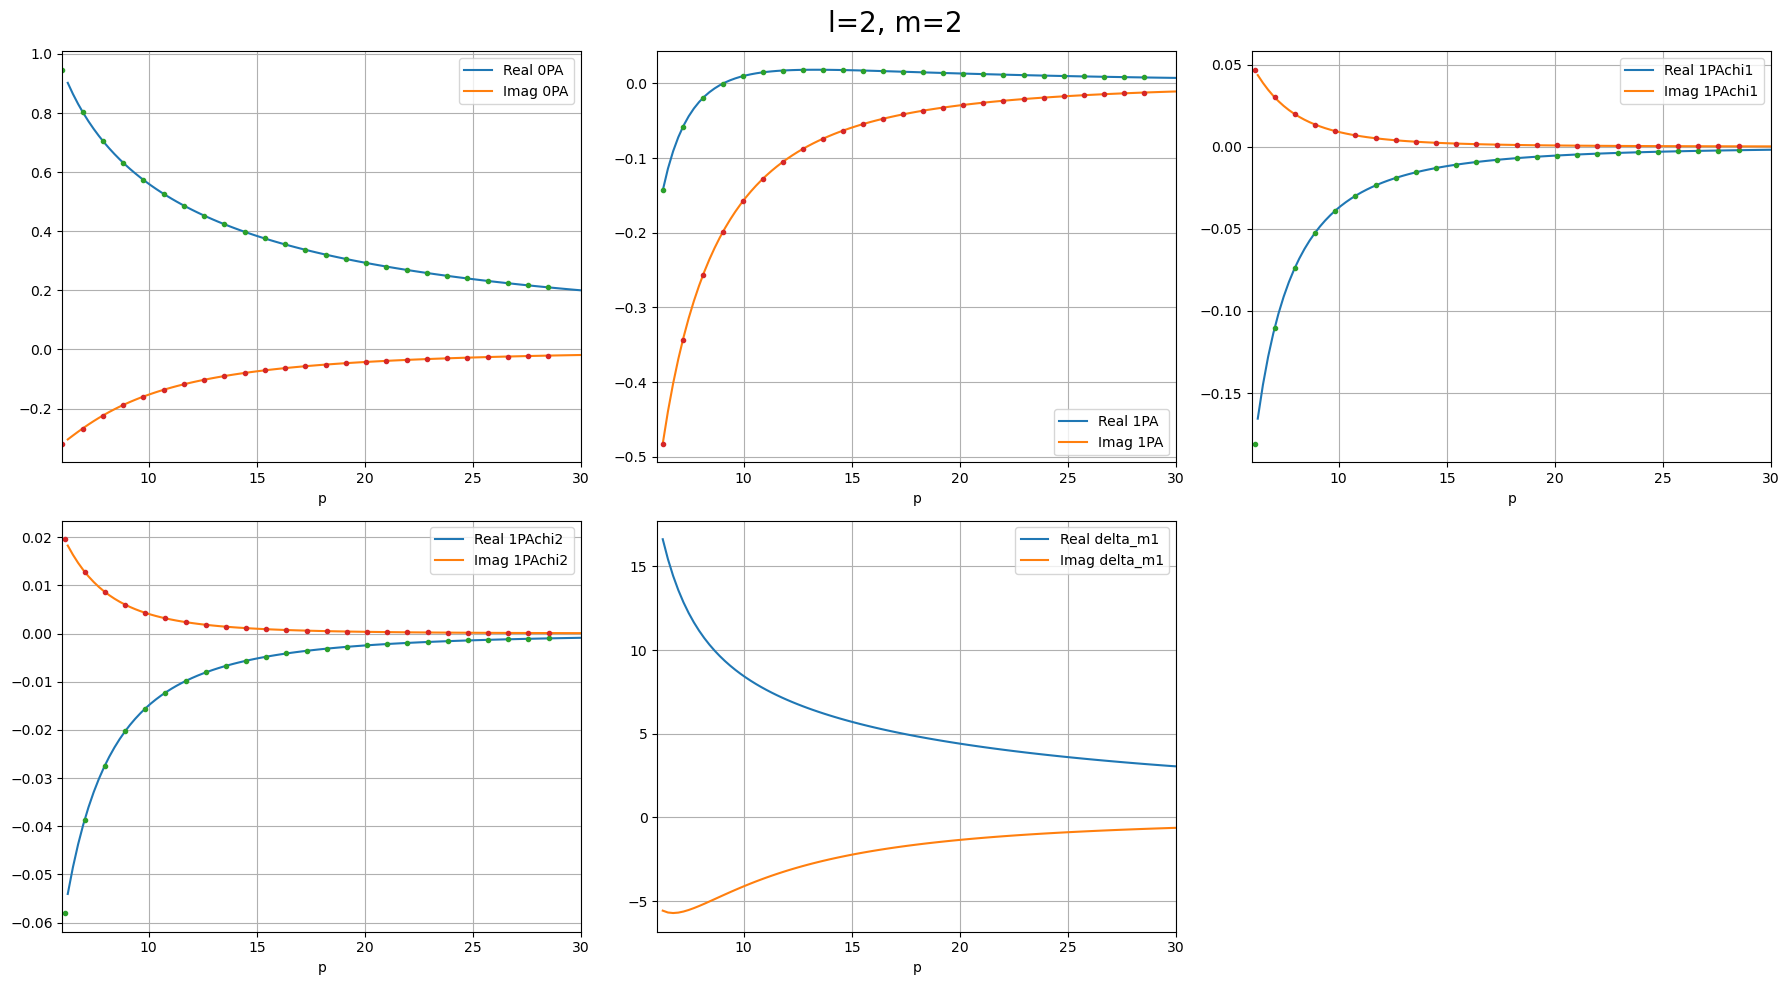

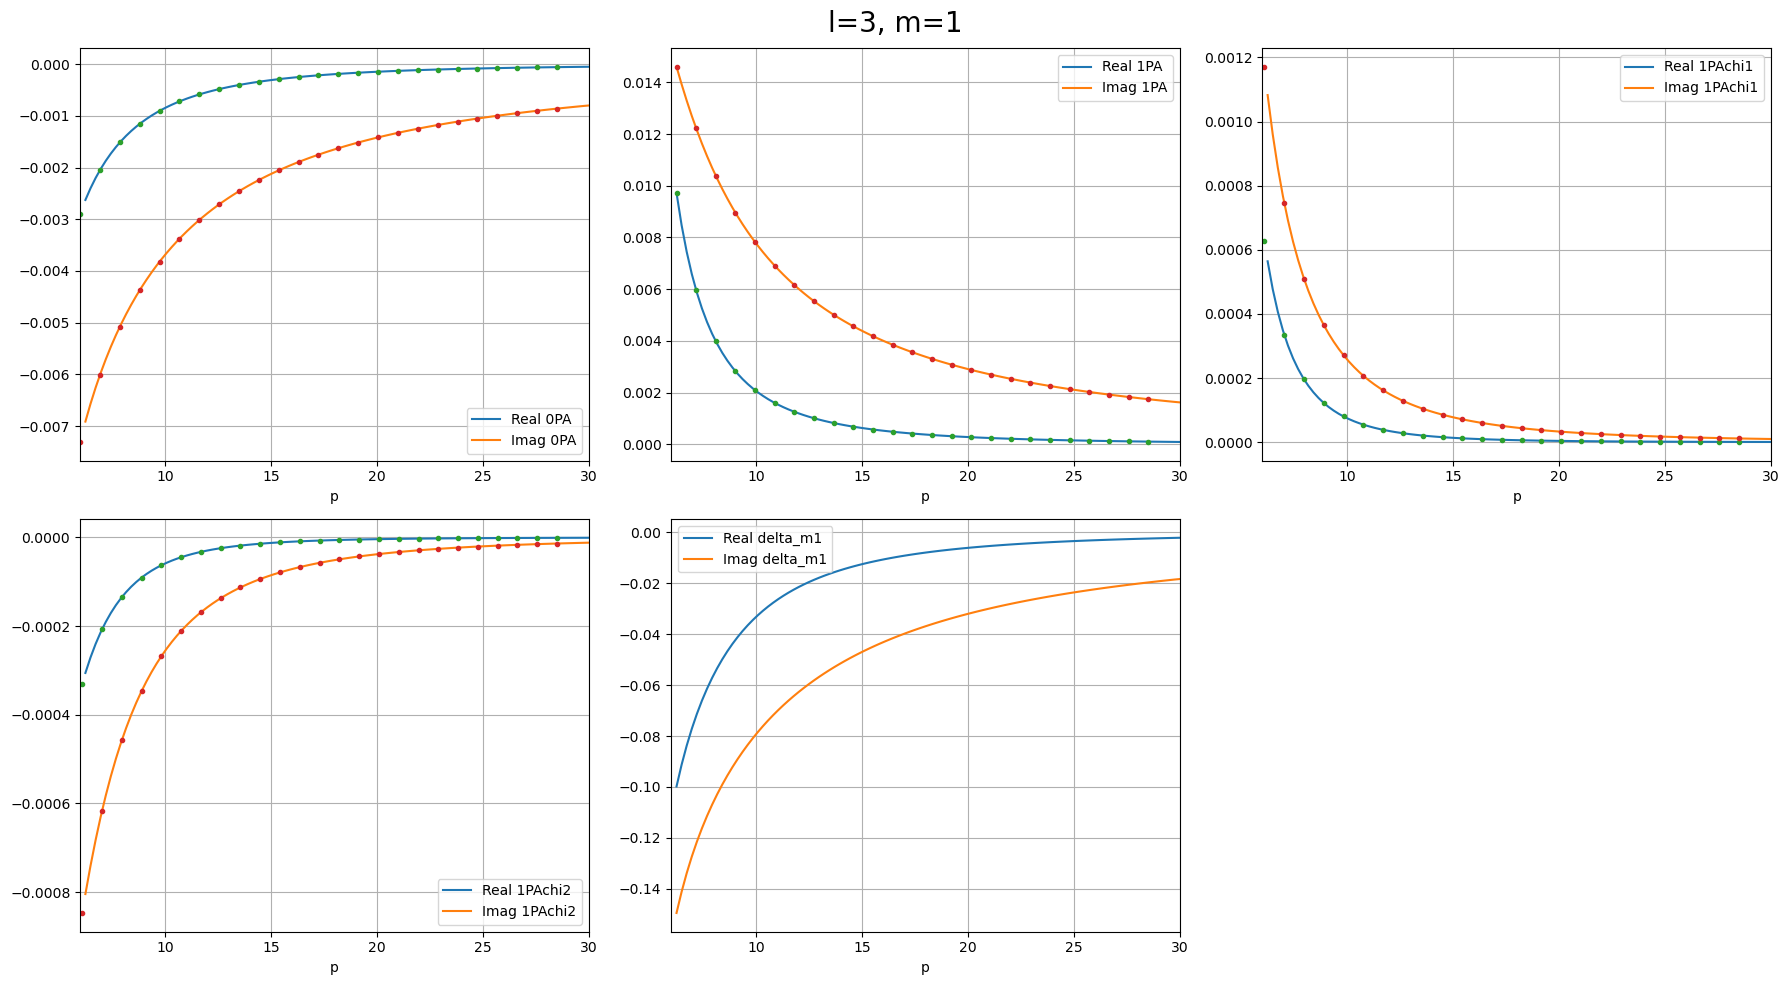

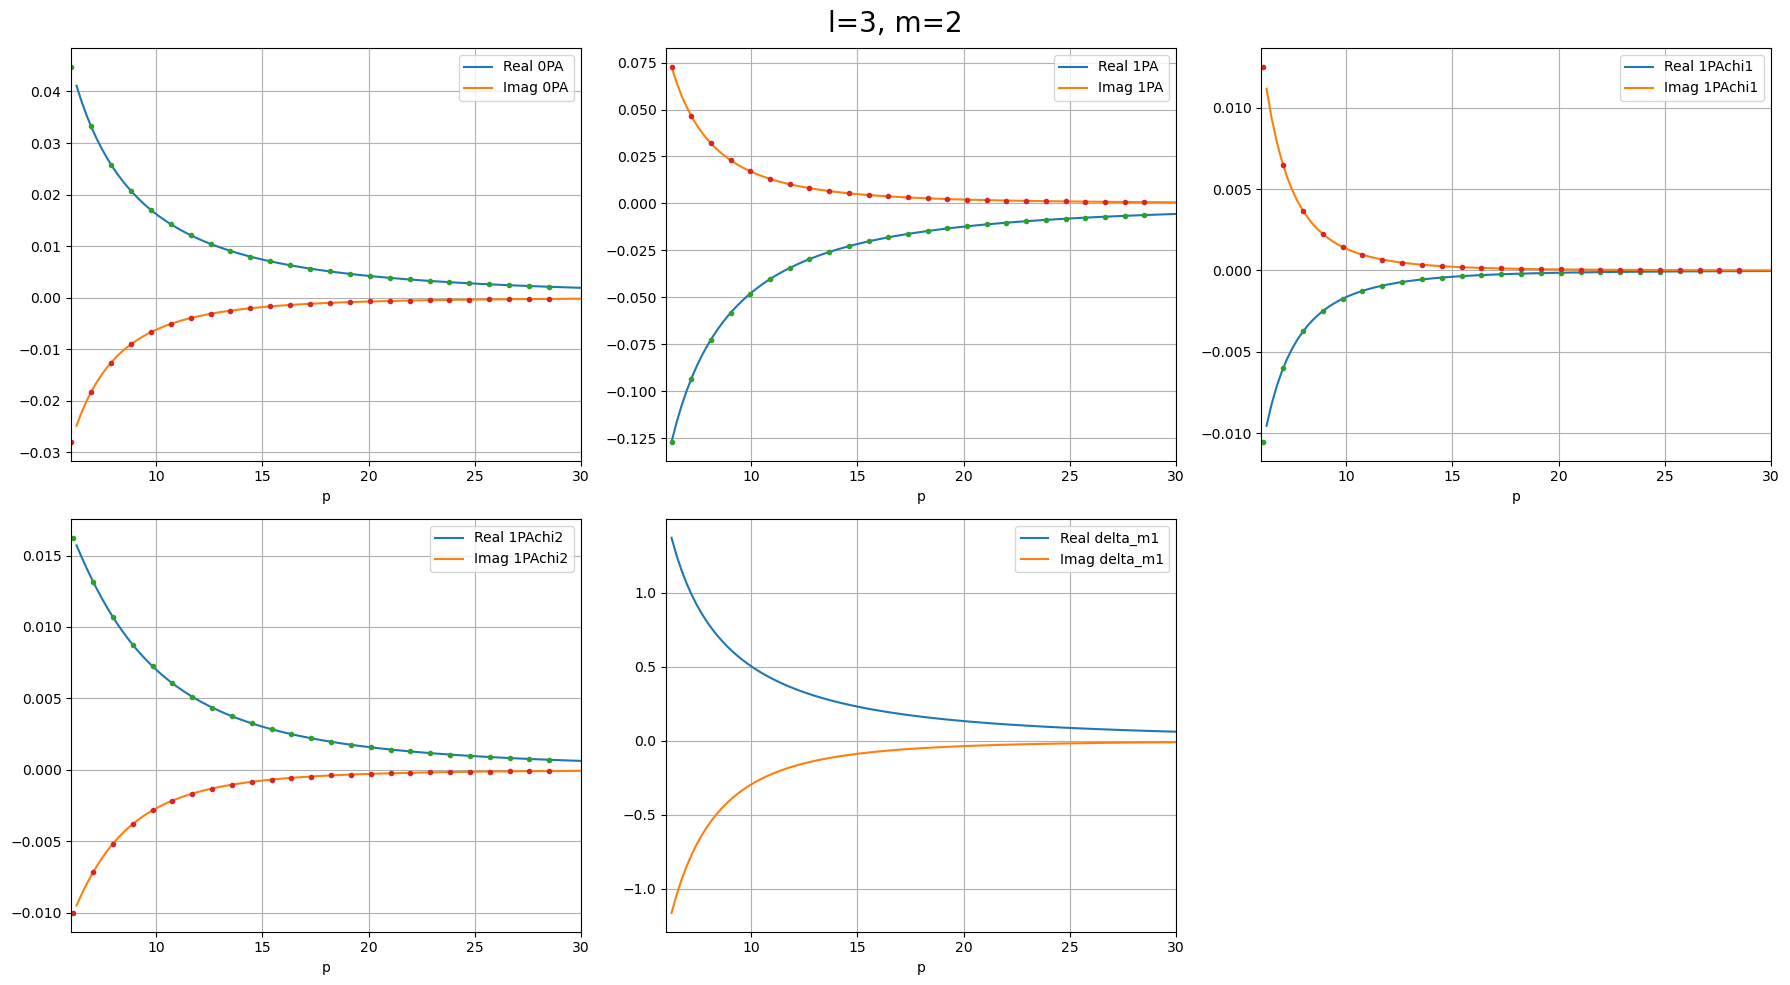

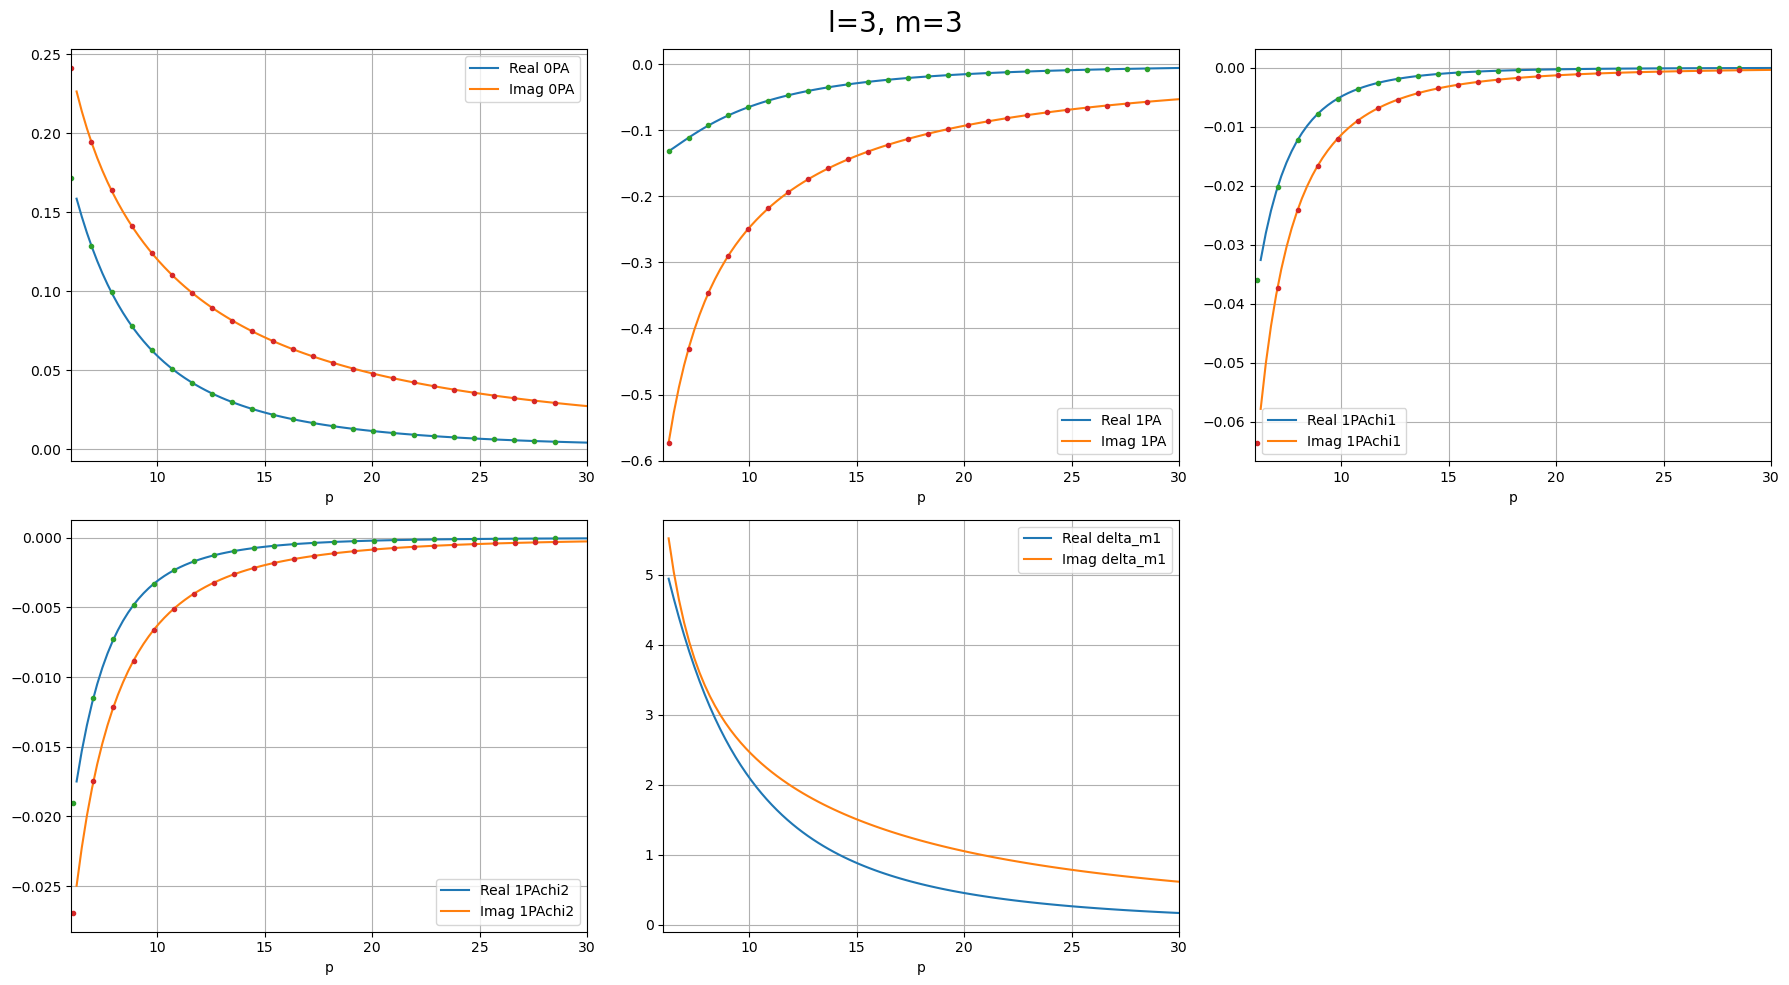

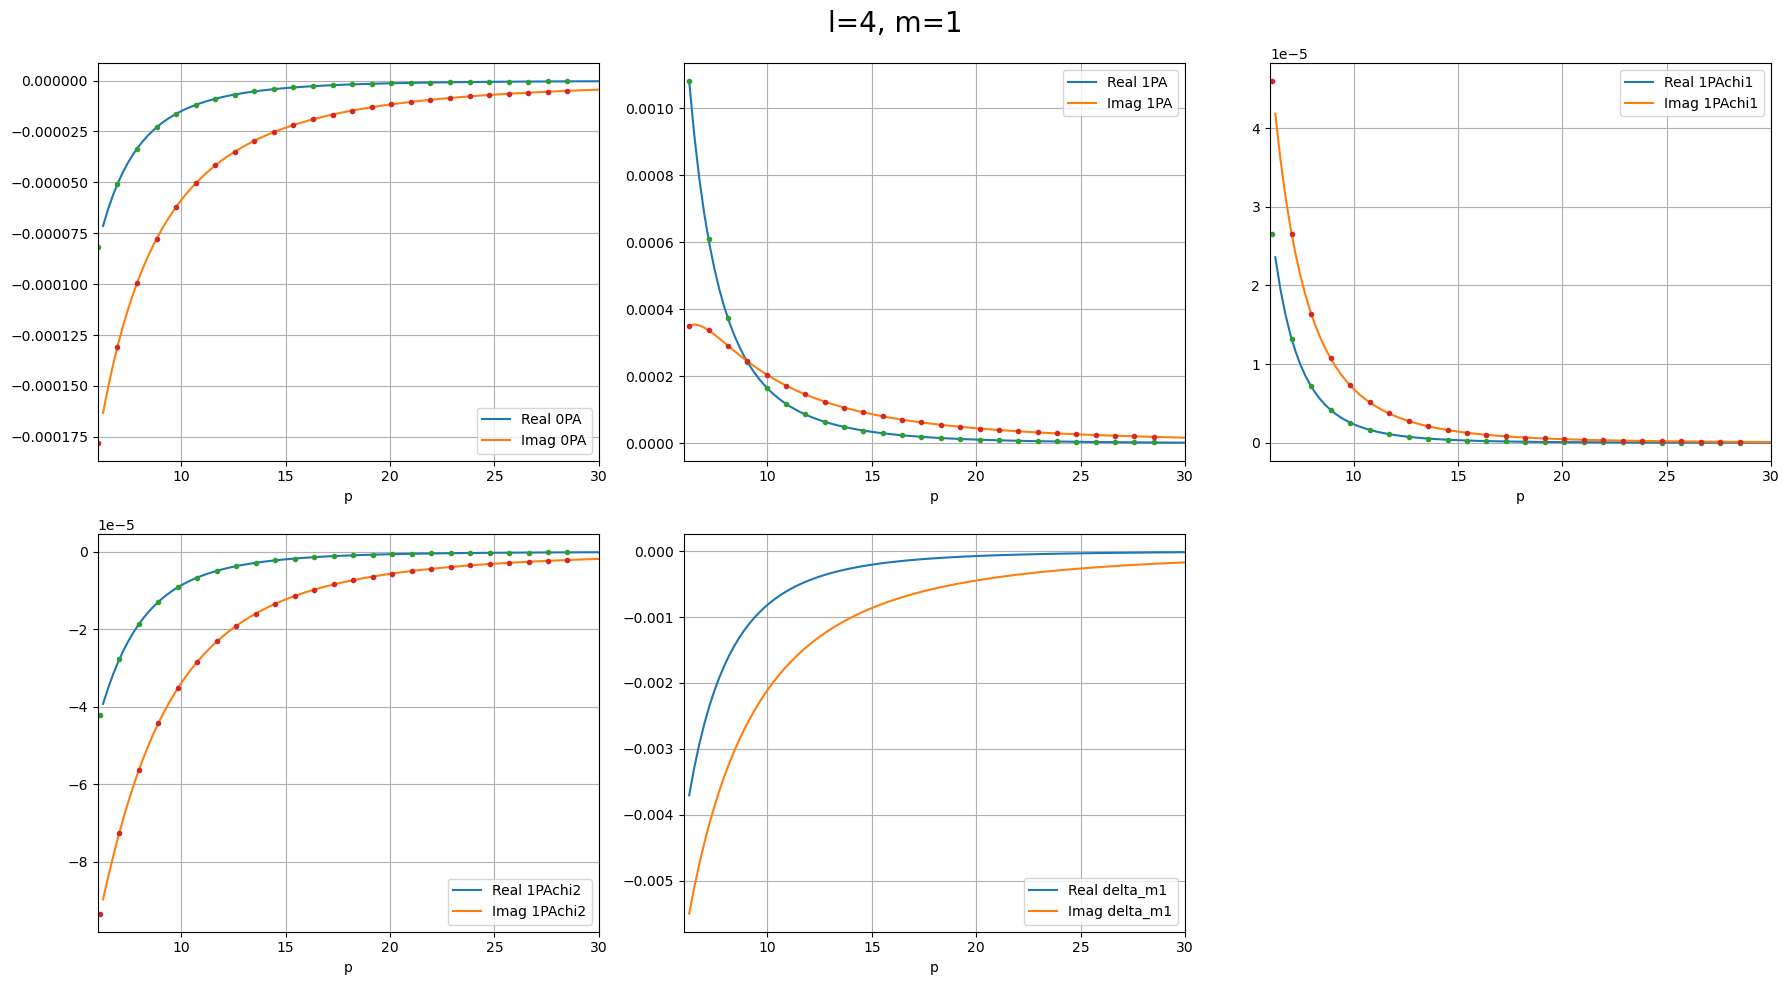

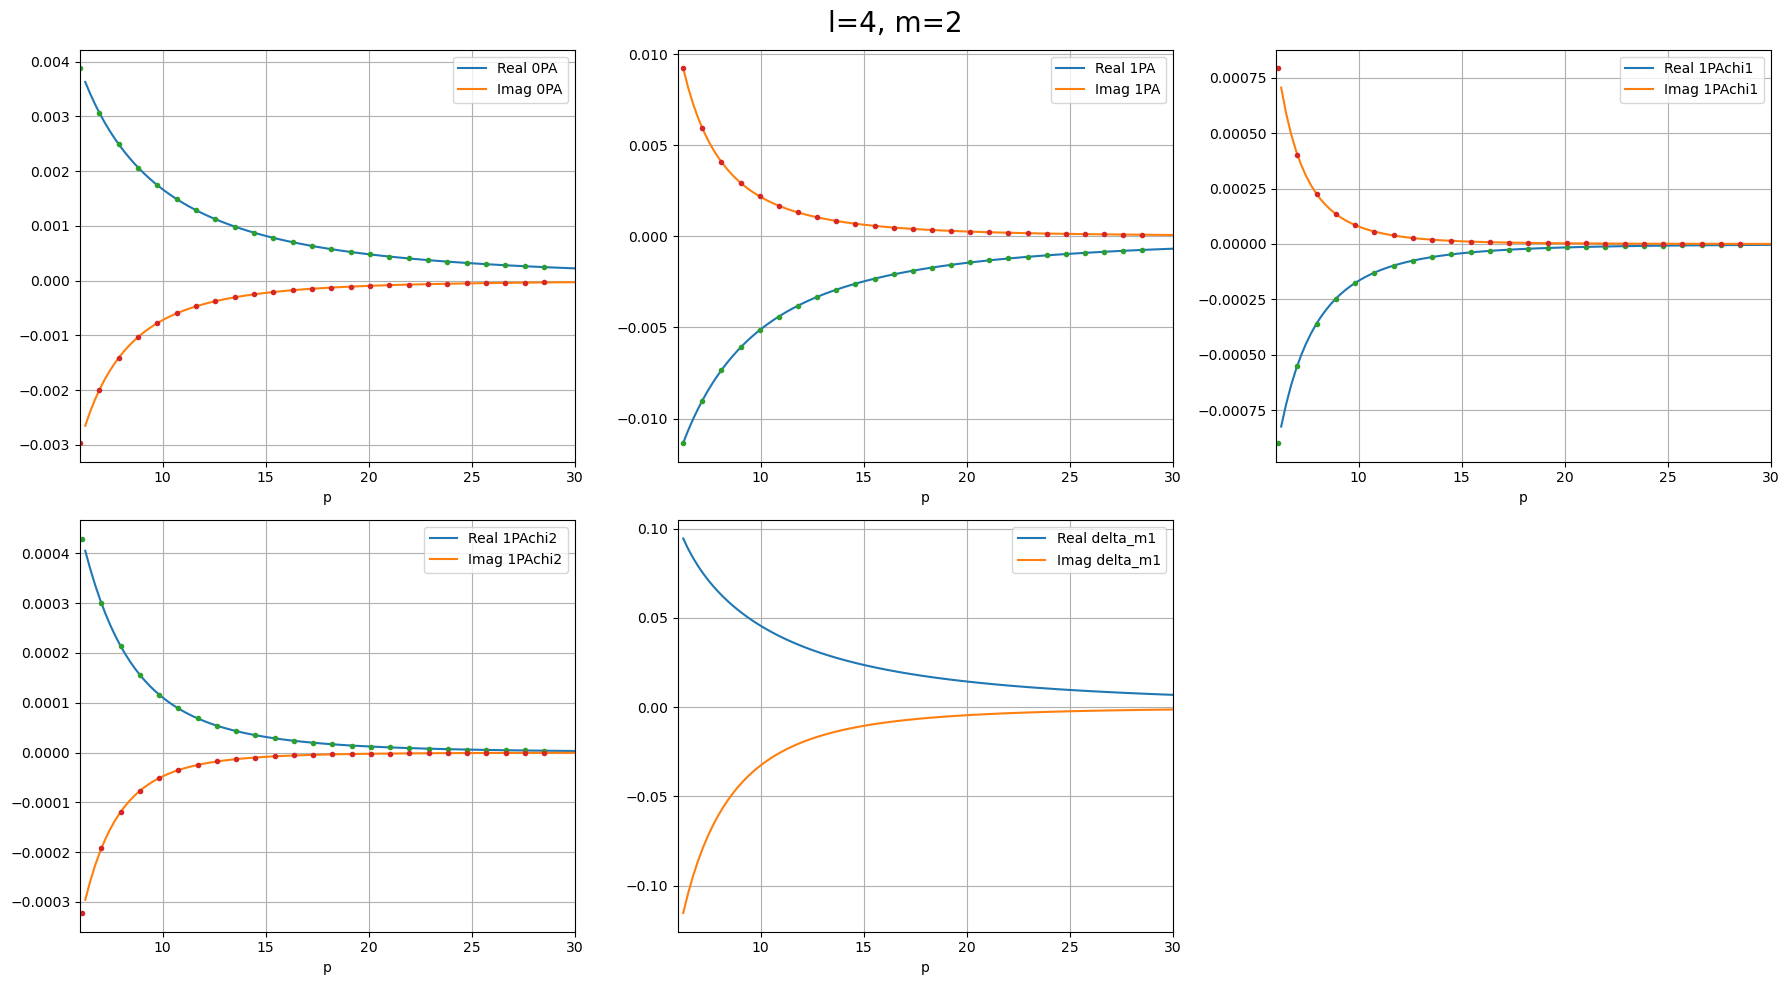

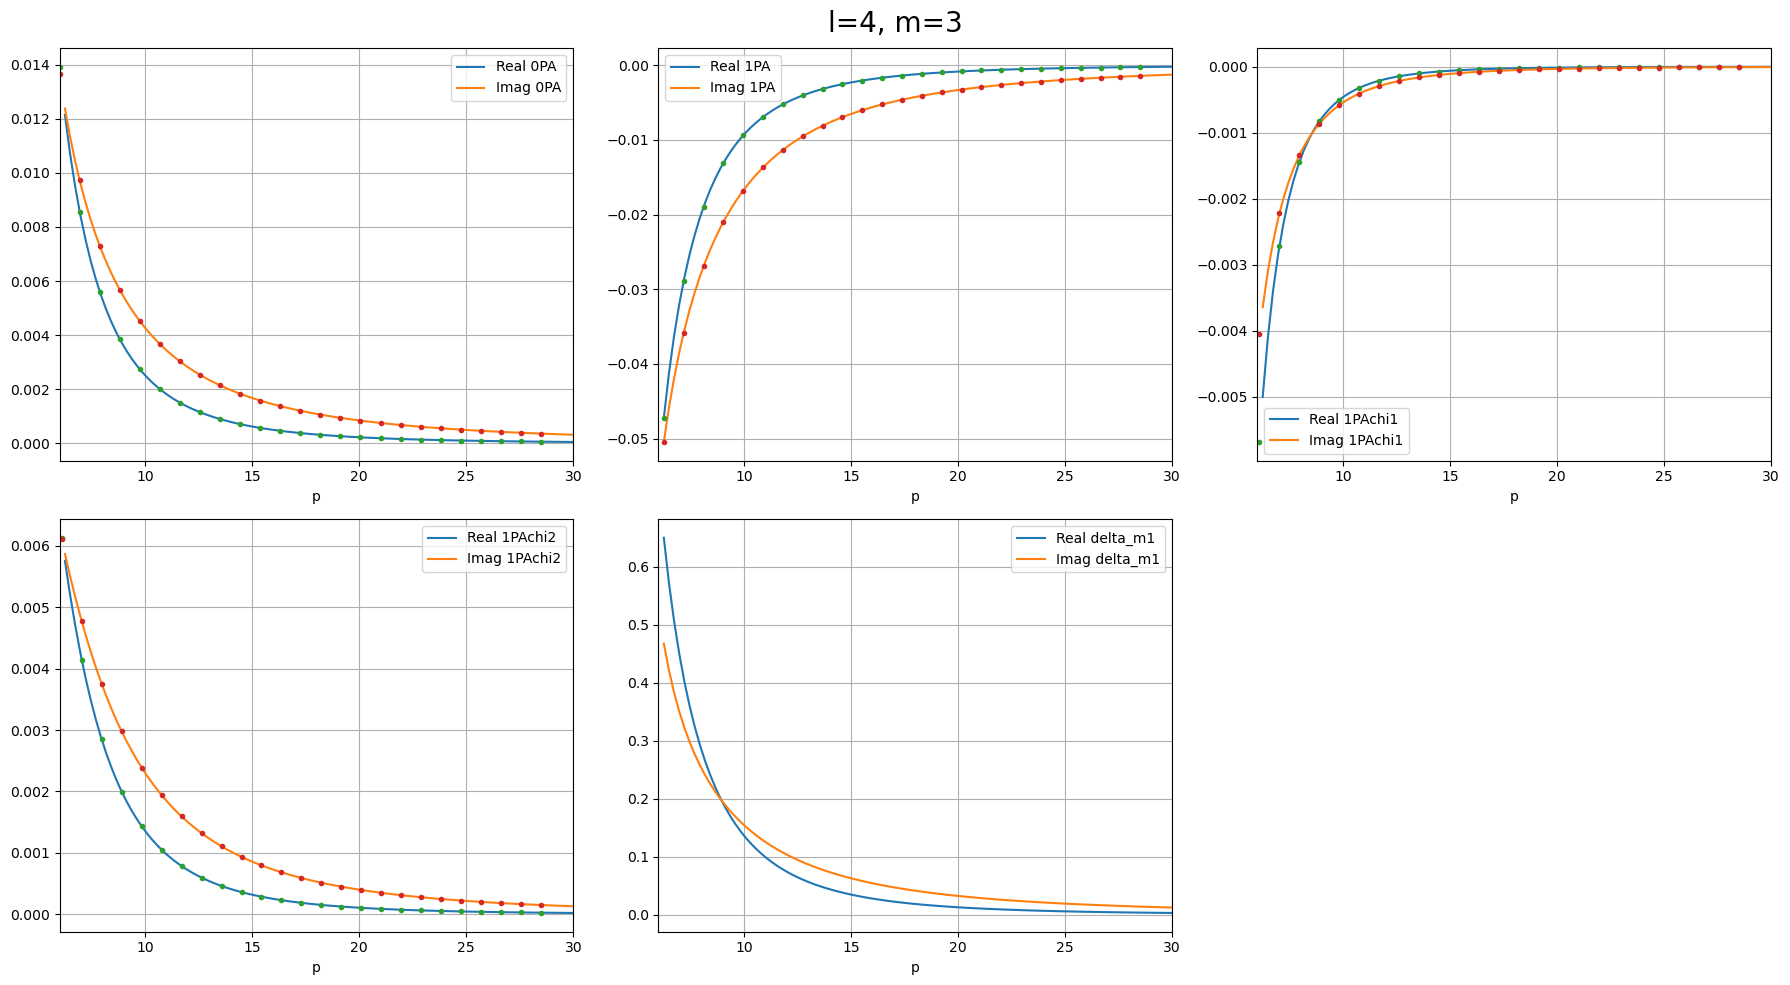

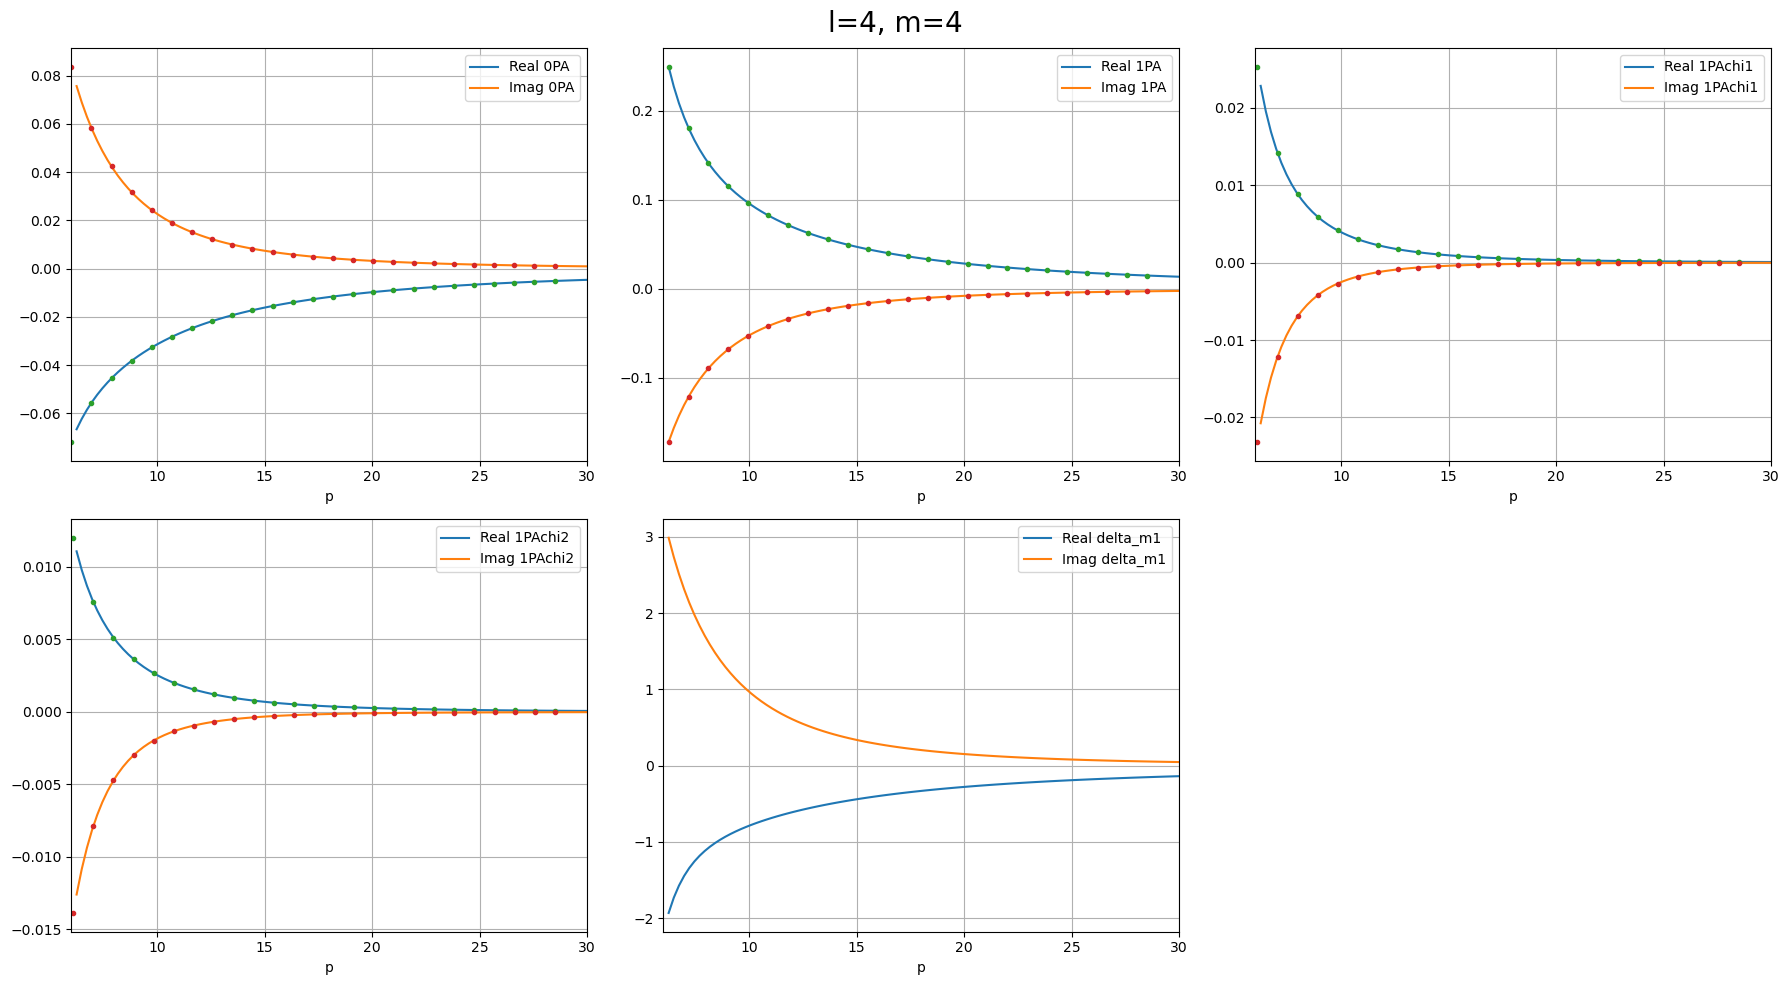

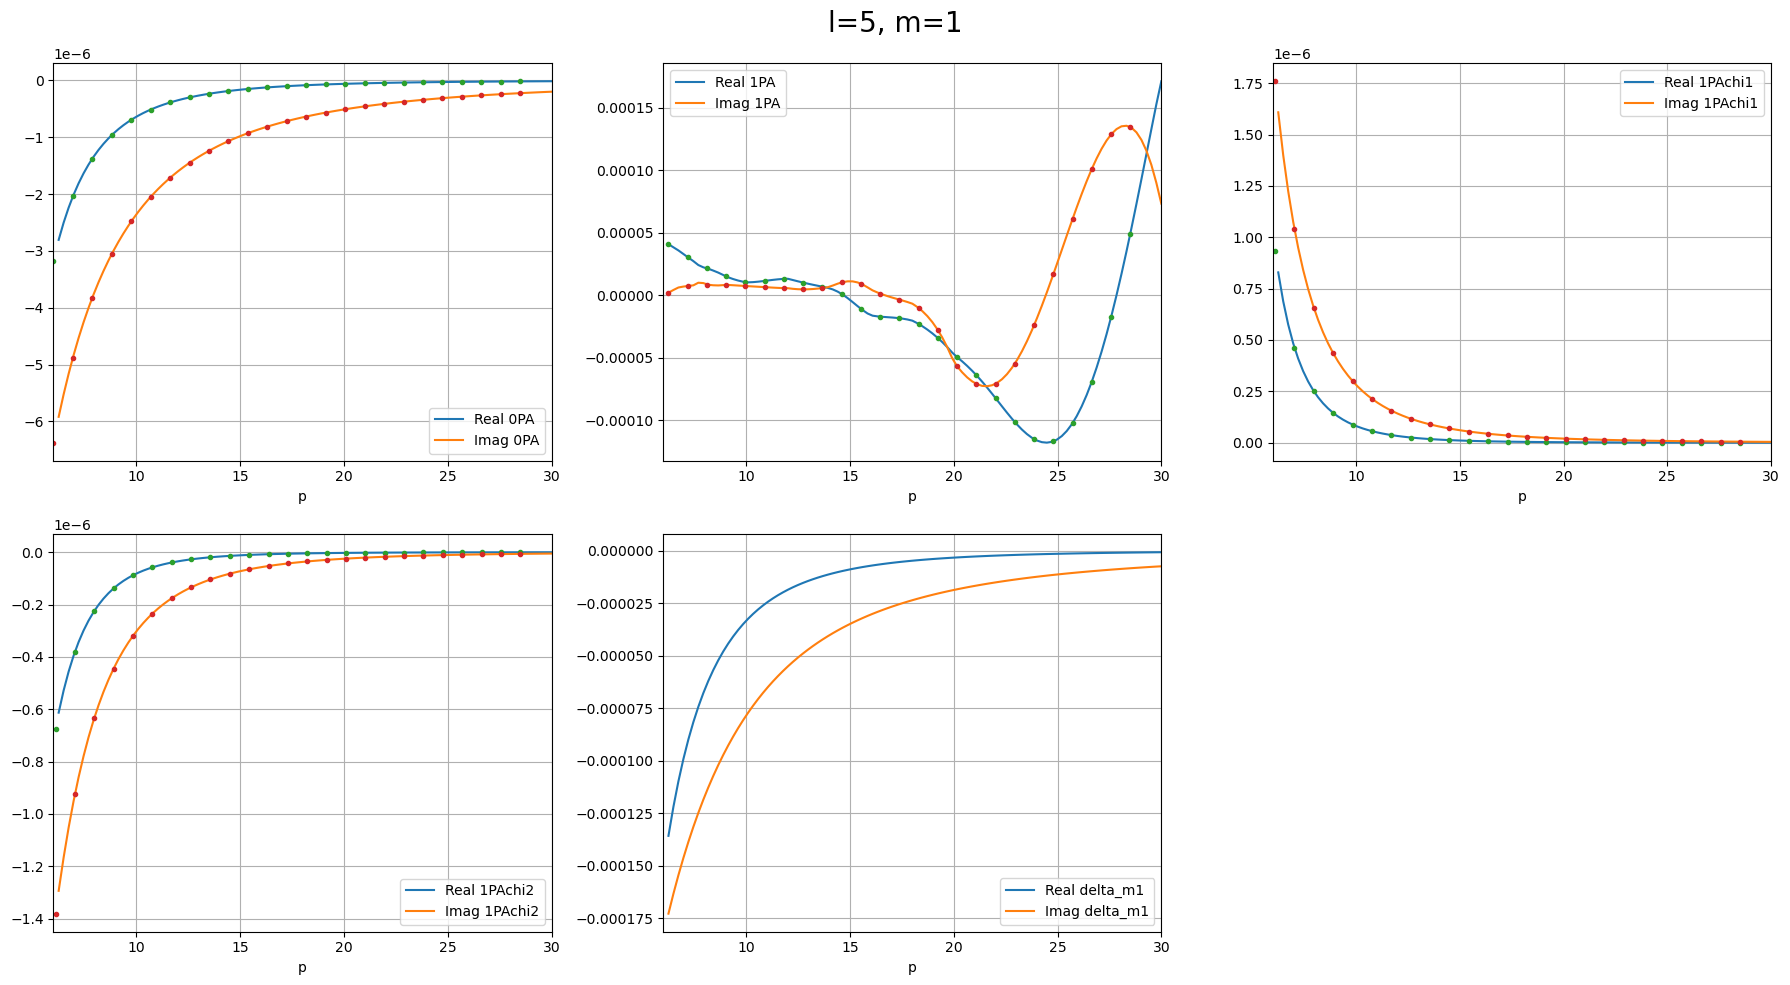

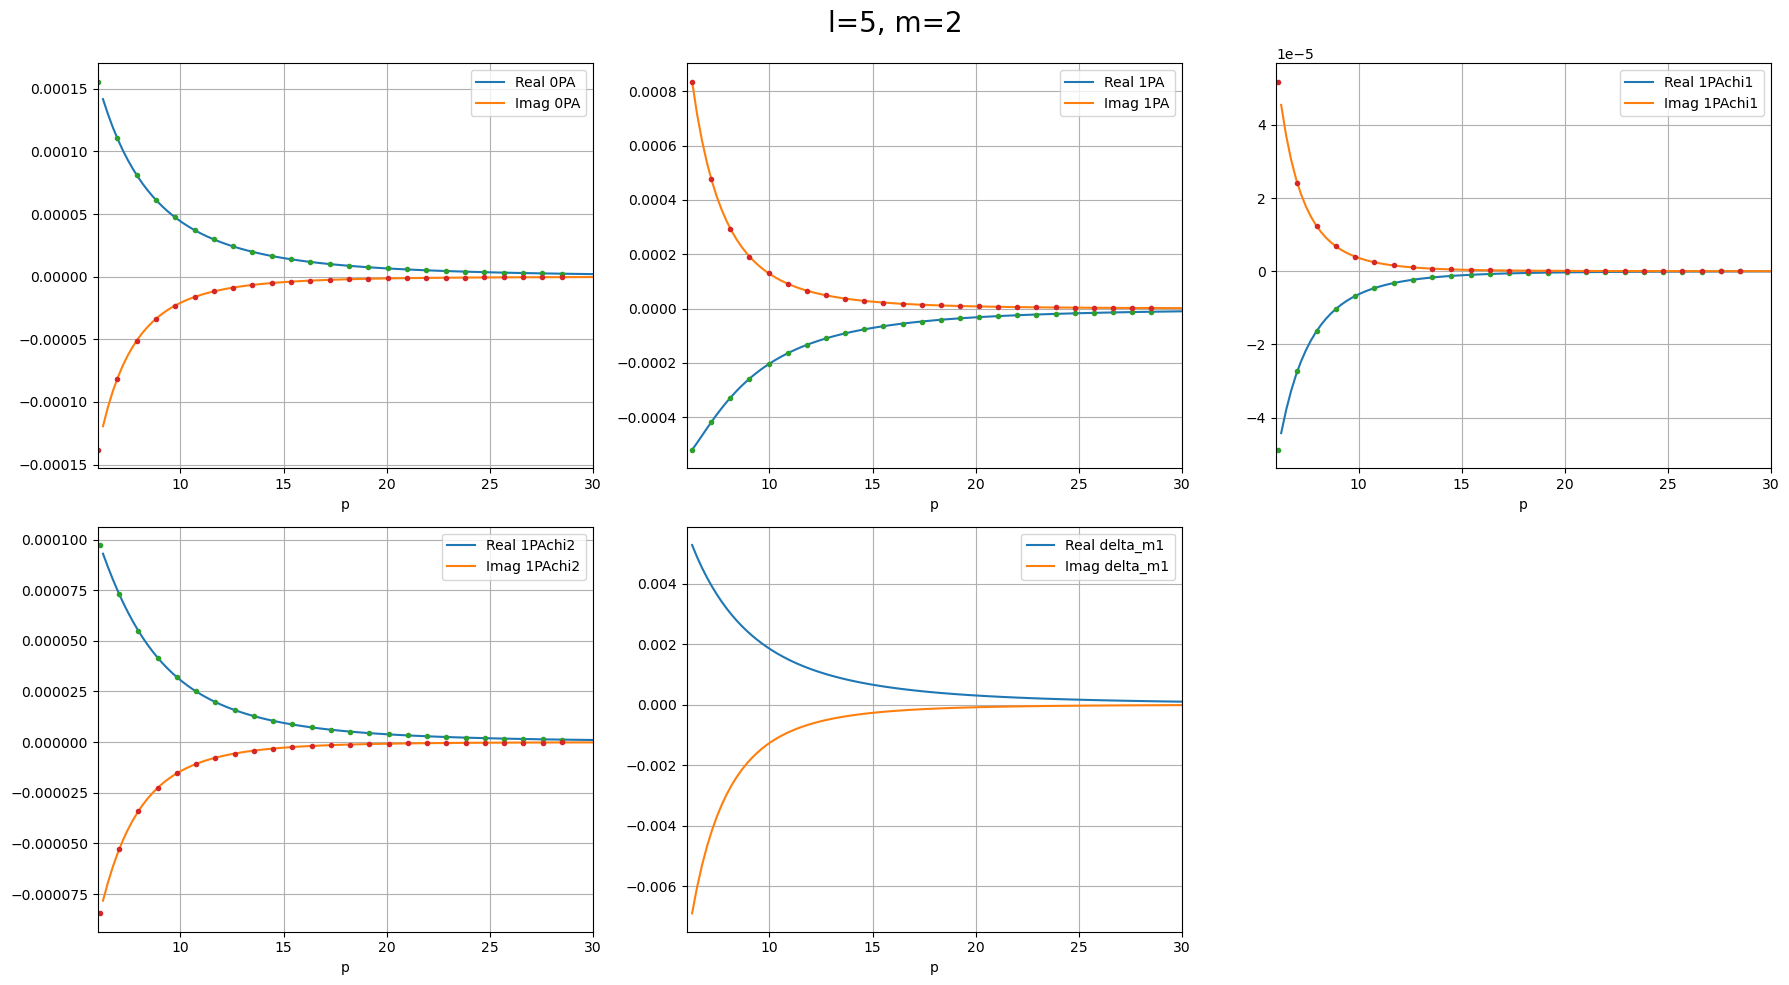

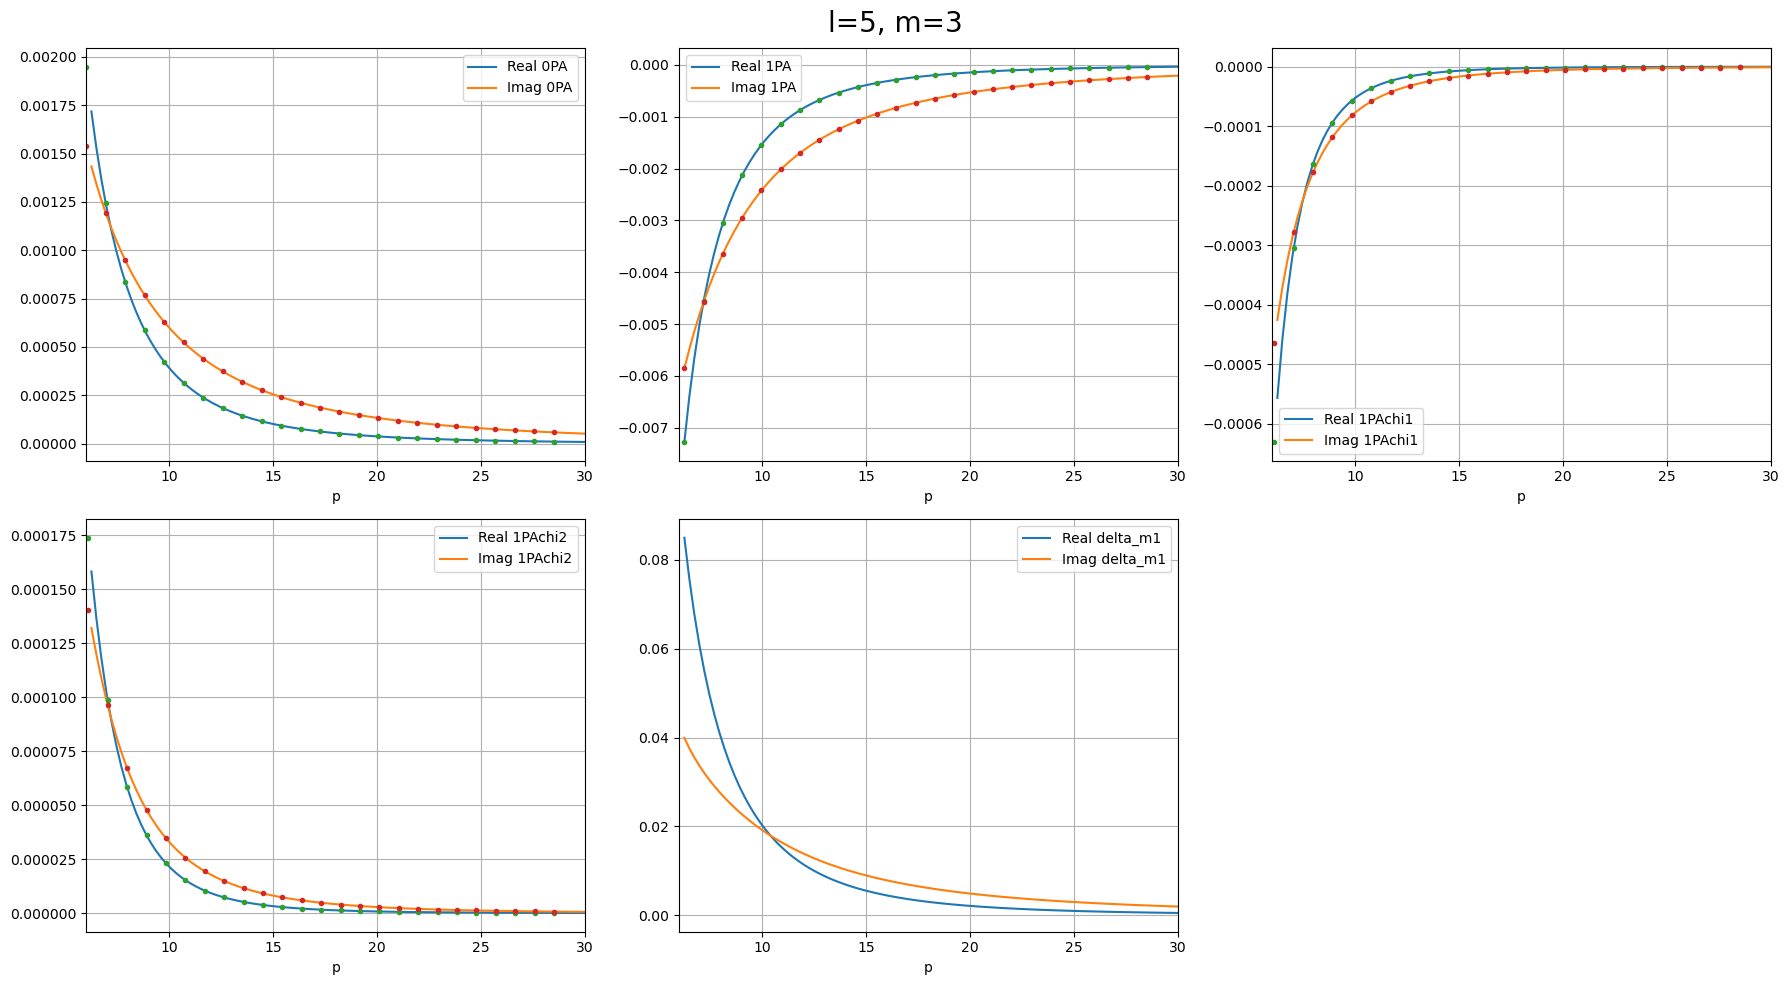

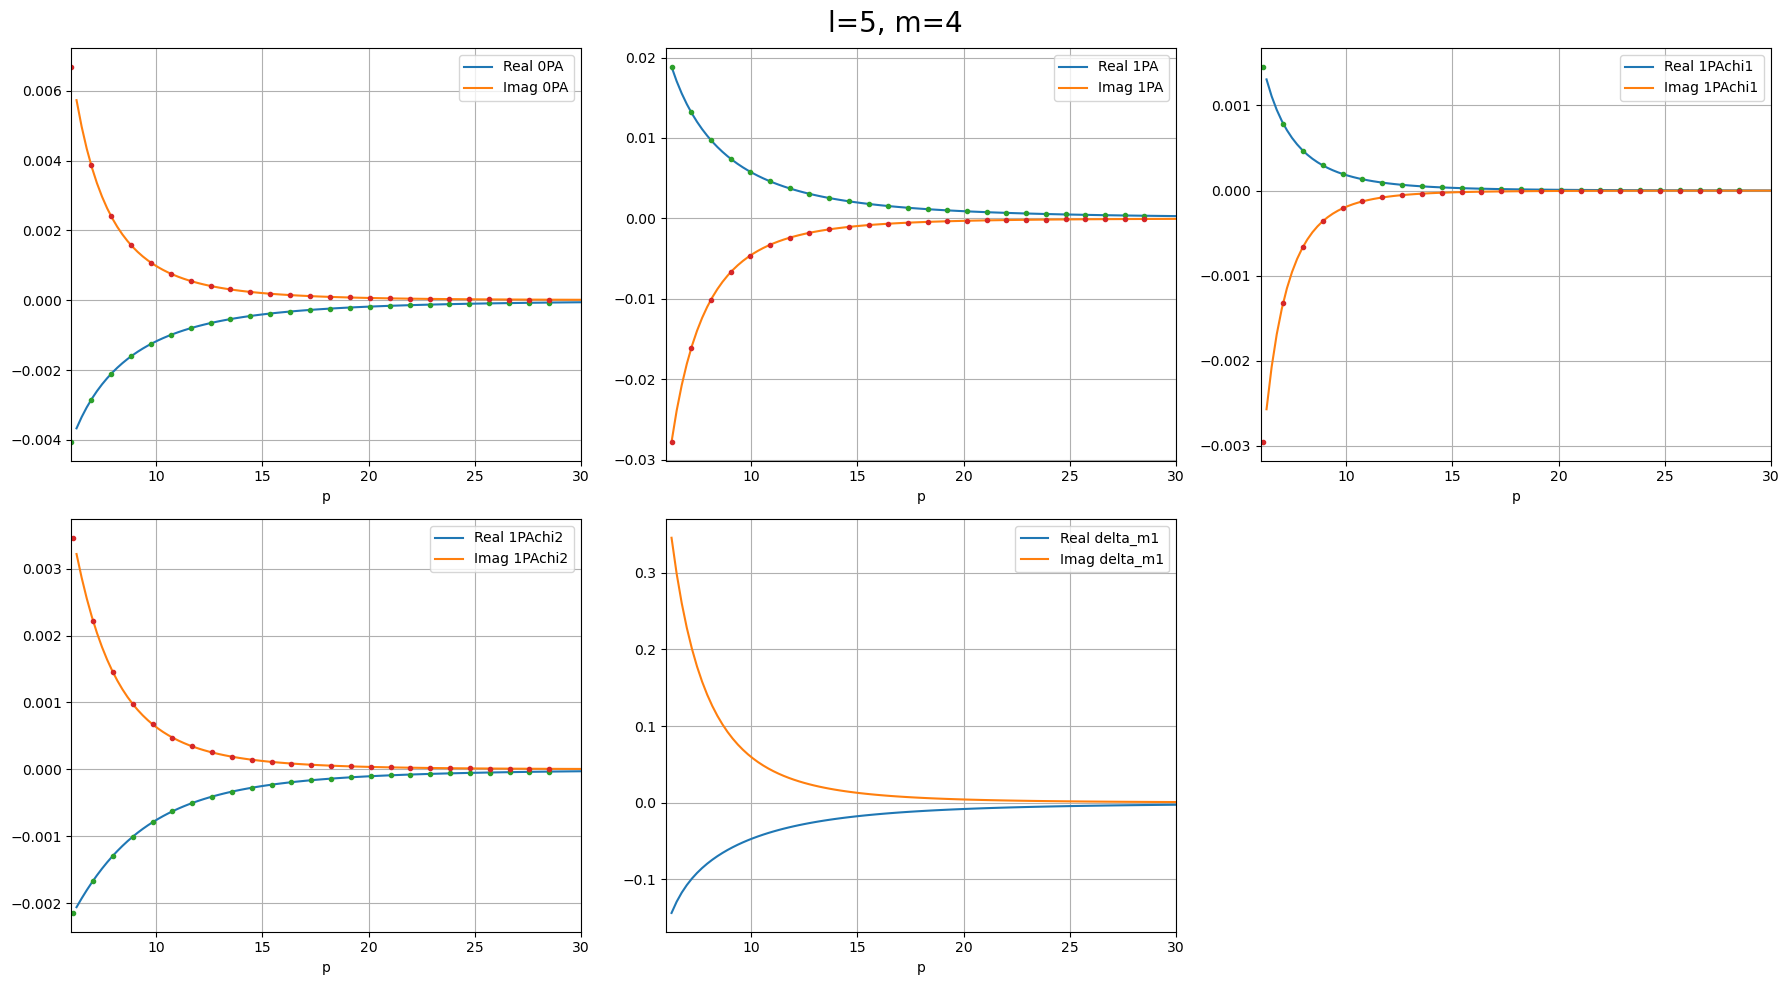

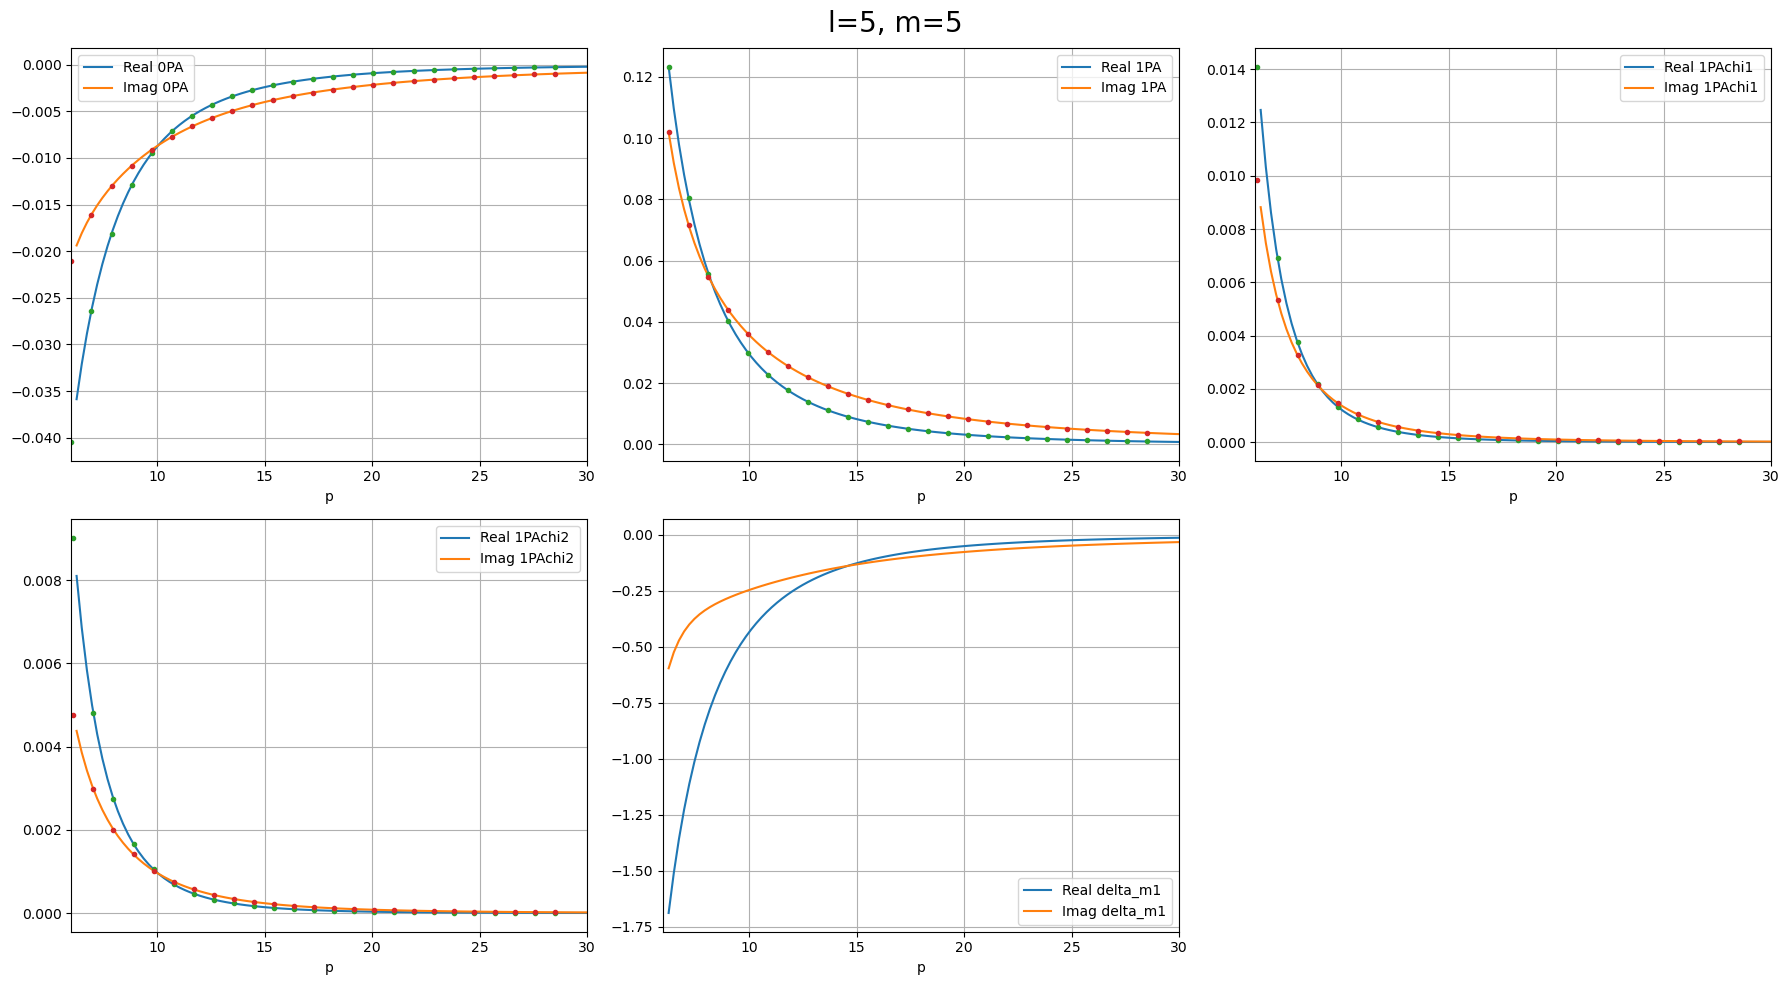

In [34]:
# Plot all modes
for pair in lm_arr:
    l, m = pair
    plot_mode_interpolant_vs_nodes(l, m)

## Batched evaluation (single component)

Confirm that evaluating the amplitudes on an array of p values returns the same result as evaluating at each p individually

In [35]:
p_values = np.linspace(6.25, 30, 100)
chosen_lm = (4,2); chosen_idx = amp.special_index_map[(chosen_lm[0], chosen_lm[1], 0, 0)];

amp_lm_arr = amp.get_amplitudes_single_piece(a, p_values, e, 1.0)[:, chosen_idx];
amp_lm_arr_direct = np.array([amp.get_amplitudes_single_piece(a, p, e, 1.0)[0, chosen_idx] for p in p_values])

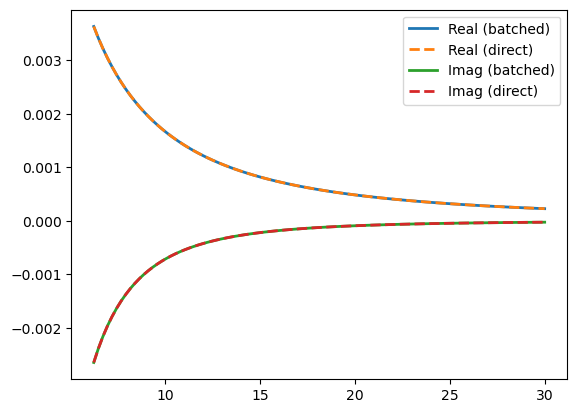

In [36]:
plt.plot(p_values, amp_lm_arr.real, lw=2.0, label="Real (batched)")
plt.plot(p_values, amp_lm_arr_direct.real, '--', lw=2.0, label="Real (direct)")

plt.plot(p_values, amp_lm_arr.imag, lw=2.0, label="Imag (batched)")
plt.plot(p_values, amp_lm_arr_direct.imag, '--', lw=2.0, label="Imag (direct)")

plt.legend()

In [37]:
np.abs(amp_lm_arr - amp_lm_arr_direct)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## Check specific mode evaluation works (single piece)

Check that the specific_modes flag functions as intended in get_amplitudes_single_piece

In [38]:
amp.get_amplitudes_single_piece(a, 7.0, e, xI, specific_modes=[(2,2,0,0), (2,1,0,0)])

{(2, 2, 0, 0): array([0.79623335-0.26433922j]),
 (2, 1, 0, 0): array([-0.03395363-0.1211271j])}

In [39]:
amp.get_amplitudes_single_piece(a, 7.0, e, xI)[:, amp.special_index_map[(2,2,0,0)]]

array([0.79623335-0.26433922j])

In [40]:
amp.get_amplitudes_single_piece(a, 7.0, e, xI)[:, amp.special_index_map[(2,1,0,0)]]

array([-0.03395363-0.1211271j])

0j


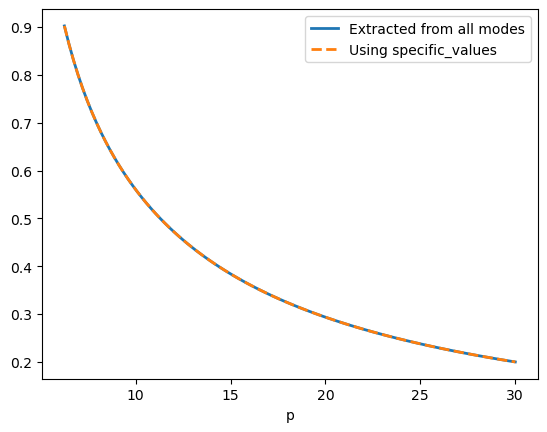

In [41]:
amp22_specific_val = amp.get_amplitudes_single_piece(a, p_values, e, xI, specific_modes=[(2,2,0,0), (2,1,0,0)])[(2,2,0,0)]
amp22 = amp.get_amplitudes_single_piece(a, p_values, e, xI)[:, amp.special_index_map[(2,2,0,0)]]
print(np.max(amp22_specific_val - amp22))

plt.plot(p_values, amp22, lw=2.0, label="Extracted from all modes")
plt.plot(p_values, amp22_specific_val, '--', lw=2.0, label="Using specific_values")
plt.xlabel("p")
plt.legend()

## Evaluate combined amplitudes

Return the combined 1PA amplitude and check it agrees with a manually combined result.

In [42]:
nu=0.1; 
chit2=0.4;
delta_m1=0.1;
chit1=0.11;
combined_amps = amp.get_amplitudes(0, 7.0, 0.0, 1.0, nu=nu,chit=chit1, chit2=chit2, delta_m1=delta_m1)

In [43]:
amps_0PA = amp.get_amplitudes_single_piece(0, 7.0, 0.0, 1.0, data_key="0PA")
amps_1PA = amp.get_amplitudes_single_piece(0, 7.0, 0.0, 1.0, data_key="1PA")
amps_1PAchi1 = amp.get_amplitudes_single_piece(0, 7.0, 0.0, 1.0, data_key="1PAchi1")
amps_1PAchi2 = amp.get_amplitudes_single_piece(0, 7.0, 0.0, 1.0, data_key="1PAchi2")
amps_deltam1 = amp.get_amplitudes_single_piece(0, 7.0, 0.0, 1.0, data_key="1PAdeltam")

tmp_amps = amps_0PA + nu*amps_1PA + chit1*amps_1PAchi1 + chit2*amps_1PAchi2 + nu*delta_m1*amps_deltam1 # does not account for the overall_factor applied for odd m modes

#Apply the resummation for odd m modes
overall_factor = np.sqrt(1 - 4 * nu)
odd_m_mask = amp.xp.asarray(amp.m_arr_no_mask % 2 != 0)[None, :]
odd_m_correction = amp.xp.where(odd_m_mask, 2 * nu * amps_0PA, 0.0)
scale = amp.xp.where(odd_m_mask, overall_factor, 1.0)

directly_combined_amps = scale * (tmp_amps + odd_m_correction)

In [44]:
print(directly_combined_amps-combined_amps)

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


Now check that it works when evaluating a specific mode

[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


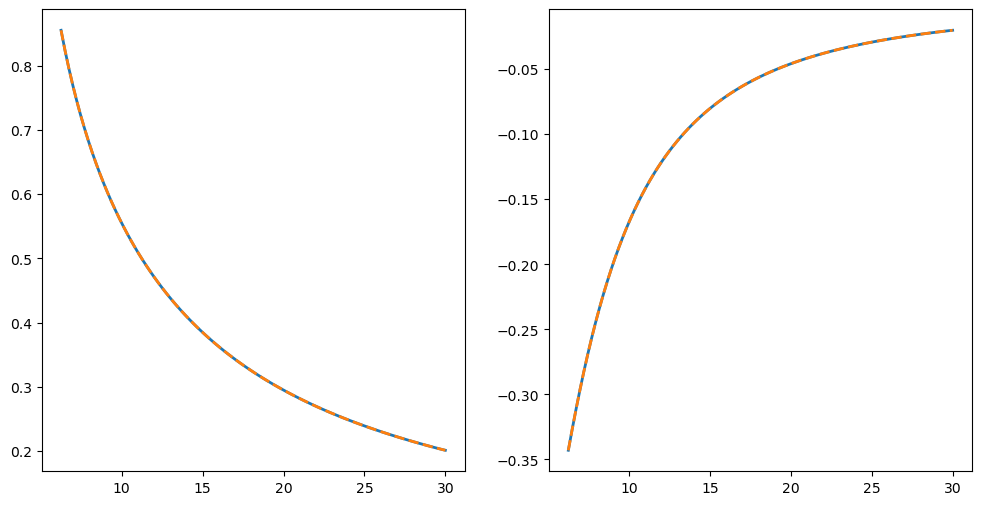

In [45]:
# Try evaluating a specific mode
combined_amp22 = amp.get_amplitudes(0, p_values, 0.0, 1.0, nu=nu, chit=chit1,chit2=chit2, delta_m1=delta_m1,specific_modes=[(2,2,0,0)])[(2,2,0,0)]
amp22_0PA = amp.get_amplitudes_single_piece(0, p_values, 0.0, 1.0, data_key="0PA", specific_modes=[(2,2,0,0)])[(2,2,0,0)]
amp22_1PA = amp.get_amplitudes_single_piece(0, p_values, 0.0, 1.0, data_key="1PA", specific_modes=[(2,2,0,0)])[(2,2,0,0)]
amp22_1PAchi1 = amp.get_amplitudes_single_piece(0, p_values, 0.0, 1.0, data_key="1PAchi1", specific_modes=[(2,2,0,0)])[(2,2,0,0)]
amp22_1PAchi2 = amp.get_amplitudes_single_piece(0, p_values, 0.0, 1.0, data_key="1PAchi2", specific_modes=[(2,2,0,0)])[(2,2,0,0)]
amp22_deltam1 = amp.get_amplitudes_single_piece(0, p_values, 0.0, 1.0, data_key="1PAdeltam", specific_modes=[(2,2,0,0)])[(2,2,0,0)]
directly_combined_amp22 = amp22_0PA + nu*amp22_1PA + chit1*amp22_1PAchi1 + chit2*amp22_1PAchi2 + nu*delta_m1*amp22_deltam1; #does not account for the overall factor applied for odd m modes

print(combined_amp22 - directly_combined_amp22)
plt.gcf().set_size_inches(12, 6)
plt.subplot(121)
plt.plot(p_values, combined_amp22.real, label="get_amplitudes", lw=2.0)
plt.plot(p_values, directly_combined_amp22.real, '--', label="manually combined", lw=2.0)

plt.subplot(122)
plt.plot(p_values, combined_amp22.imag, label="get_amplitudes", lw=2.0)
plt.plot(p_values, directly_combined_amp22.imag, '--', label="manually combined", lw=2.0)

## Quick timing

In [46]:
from few.amplitude.ampinterp1d import AmpInterp1PAT1R
amp = AmpInterp1PAT1R()

In [47]:
%timeit amp.get_amplitudes(0, 7.0, 0.0, 1.0, nu=nu, chit=chit1, chit2=chit2, delta_m1=delta_m1)
%timeit amp.get_amplitudes(0, np.linspace(6.25, 29.0, 101), 0.0, 1.0, nu=nu, chit=chit1, chit2=chit2, delta_m1=delta_m1)
%timeit amps_0PA = amp.get_amplitudes_single_piece(0, 7.0, 0.0, 1.0, data_key="0PA")
%timeit amps_1PA = amp.get_amplitudes_single_piece(0, 7.0, 0.0, 1.0, data_key="1PA")
%timeit amps_1PAchi1 = amp.get_amplitudes_single_piece(0, 7.0, 0.0, 1.0, data_key="1PAchi1")
%timeit amps_1PAchi2 = amp.get_amplitudes_single_piece(0, 7.0, 0.0, 1.0, data_key="1PAchi2")
%timeit amps_1PAdeltam = -(2./3.*7)*amp.get_amplitudes_single_piece(0, 7.0, 0.0, 1.0, data_key="0PA", deriv_order=1)

1.05 ms ± 35.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.02 ms ± 78.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
224 μs ± 31.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
221 μs ± 24.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
389 μs ± 84.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
352 μs ± 84.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
340 μs ± 92.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
